In [22]:
## 0. Environment & Data Setup

In [23]:
from pathlib import Path
import os

IN_COLAB = Path("/content").exists()

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DATA_ROOT = Path(
        "/content/drive/MyDrive/MT-Hackathon-2026/data"
    )
else:
    # notebook находится в ml/notebooks/
    DATA_ROOT = Path("../../data").resolve()

print("Environment:", "Colab" if IN_COLAB else "Local")
print("DATA_ROOT:", DATA_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Colab
DATA_ROOT: /content/drive/MyDrive/MT-Hackathon-2026/data


In [24]:
PROCESSED_DIR = DATA_ROOT / "processed"
LABELS_DIR = DATA_ROOT / "labels"

TRAIN_HOURLY_PATH = PROCESSED_DIR / "baseline_train_hourly.csv"
VALID_HOURLY_PATH = PROCESSED_DIR / "baseline_validation_hourly.csv"

LABELS_TRAIN_PATH = LABELS_DIR / "labels_day_train.csv"
LABELS_TEST_PATH = LABELS_DIR / "labels_day_test.csv"

In [25]:
paths = [
    TRAIN_HOURLY_PATH,
    VALID_HOURLY_PATH,
    LABELS_TRAIN_PATH,
    LABELS_TEST_PATH,
]

for path in paths:
    print(path, "->", path.exists())

/content/drive/MyDrive/MT-Hackathon-2026/data/processed/baseline_train_hourly.csv -> True
/content/drive/MyDrive/MT-Hackathon-2026/data/processed/baseline_validation_hourly.csv -> True
/content/drive/MyDrive/MT-Hackathon-2026/data/labels/labels_day_train.csv -> True
/content/drive/MyDrive/MT-Hackathon-2026/data/labels/labels_day_test.csv -> True


In [26]:
import pandas as pd

train_hourly = pd.read_csv(TRAIN_HOURLY_PATH)
valid_hourly = pd.read_csv(VALID_HOURLY_PATH)

labels_train = pd.read_csv(LABELS_TRAIN_PATH)
labels_test = pd.read_csv(LABELS_TEST_PATH)

In [27]:
print("train_hourly:", train_hourly.shape)
print("valid_hourly:", valid_hourly.shape)
print("labels_train:", labels_train.shape)
print("labels_test:", labels_test.shape)

display(train_hourly.head())

train_hourly: (58320, 1)
valid_hourly: (14640, 1)
labels_train: (46234, 1)
labels_test: (11317, 1)


,route;date;hour;boardings
0,1;2025-01-01;0;0
1,1;2025-01-01;1;0
2,1;2025-01-01;2;0
3,1;2025-01-01;3;0
4,1;2025-01-01;4;0


**ВАЖНО:**
**Ниже не указывайте абсолютные пути Colab/Google Drive.**
**Используйте DATA_ROOT, переменные *_PATH или уже загруженные DataFrames.**

## 1. Frozen LightGBM baseline

Эта секция воспроизводит текущий baseline из `ml/src/lightgbm_baseline.py` и служит неизменяемым эталоном для последующих feature experiments.

| Параметр | Зафиксированный эталон |
|---|---|
| Целевая переменная / единица | `boardings` на `(route, date, hour)` |
| Обучение | январь–август 2025, 58 320 часовых строк |
| Временная валидация | сентябрь–октябрь 2025, непрерывный holdout, 14 640 строк |
| Признаки baseline | `route`, `weekday`, `hour` |
| Предобработка | все три признаки — `pandas.Categorical`; категории: маршруты `(1, 5, 7, 11, 12, 17, 25, 26, 28, 50)`, weekday `0…6`, hour `0…23` |
| LightGBM | `objective="regression_l1"`, `n_estimators=300`, `max_depth=6`, `num_leaves=31`, `learning_rate=0.1`, `random_state=42`, `n_jobs=4`, `verbosity=-1`; прочие параметры — по умолчанию |
| Постобработка | `floor(max(prediction, 0) + 0.5)` |
| Метрика | `WAPE = sum(abs(actual − prediction)) / sum(actual)` |

CSV загружаются через пути из `Environment & Data Setup` и с разделителем `;`. Фактический target validation открывается после построения полного прогноза. Эксперименты с признаками должны сохранять этот baseline, меняя только добавляемые признаки. Результаты появятся после запуска ячеек в Colab.

In [28]:
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor

FROZEN_ROUTES = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)
FROZEN_FEATURES = ("route", "weekday", "hour")

frozen_train = pd.read_csv(
    TRAIN_HOURLY_PATH, sep=";", parse_dates=["date"]
)
frozen_validation_keys = pd.read_csv(
    VALID_HOURLY_PATH,
    sep=";",
    usecols=["route", "date", "hour"],
    parse_dates=["date"],
)
if len(frozen_train) != 58_320 or len(frozen_validation_keys) != 14_640:
    raise ValueError("Unexpected hourly grid size")
if frozen_train["date"].max() >= frozen_validation_keys["date"].min():
    raise ValueError("Training and validation periods overlap")

def frozen_calendar_features(rows):
    return pd.DataFrame(
        {
            "route": pd.Categorical(rows["route"], categories=FROZEN_ROUTES),
            "weekday": pd.Categorical(rows["date"].dt.weekday, categories=range(7)),
            "hour": pd.Categorical(rows["hour"], categories=range(24)),
        }
    )

In [29]:
frozen_model = LGBMRegressor(
    objective="regression_l1",
    n_estimators=300,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    n_jobs=4,
    verbosity=-1,
)
frozen_model.fit(
    frozen_calendar_features(frozen_train),
    frozen_train["boardings"],
    categorical_feature=list(FROZEN_FEATURES),
)

frozen_predictions = np.floor(
    np.maximum(frozen_model.predict(frozen_calendar_features(frozen_validation_keys)), 0) + 0.5
)

# Open holdout targets only after the full forecast has been generated.
frozen_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if (
    len(frozen_actual) != len(frozen_predictions)
    or frozen_actual.sum() == 0
    or not np.isfinite(frozen_predictions).all()
):
    raise ValueError("Invalid validation targets or predictions")

frozen_absolute_error = np.abs(frozen_actual - frozen_predictions)
frozen_overall_wape = frozen_absolute_error.sum() / frozen_actual.sum()
print(f"Frozen baseline overall WAPE: {frozen_overall_wape:.6f}")

frozen_route_metrics = pd.DataFrame(
    {
        "route": frozen_validation_keys["route"],
        "actual": frozen_actual,
        "absolute_error": frozen_absolute_error,
    }
).groupby("route").agg(
    actual=("actual", "sum"),
    absolute_error=("absolute_error", "sum"),
)
frozen_route_metrics["WAPE"] = (
    frozen_route_metrics["absolute_error"]
    / frozen_route_metrics["actual"].replace(0, np.nan)
)
frozen_route_metrics = (
    frozen_route_metrics.reindex(FROZEN_ROUTES)
    .rename_axis("route")
    .reset_index()
)
print("Frozen baseline WAPE by route (NaN means zero actual boardings):")
display(frozen_route_metrics[["route", "WAPE"]].round(6))

Frozen baseline overall WAPE: 0.132223
Frozen baseline WAPE by route (NaN means zero actual boardings):


,route,WAPE
0,1,0.115082
1,5,NaN
2,7,0.154506
3,11,0.112404
4,12,0.093846
5,17,0.108239
6,25,0.198486
7,26,0.126216
8,28,0.154428
9,50,0.246597


## Hypothesis → Analysis

**H2.** Взаимодействия `route × hour` и `hour × weekend` могут отражать разные суточные профили маршрутов и типов дней.

Анализ: только `labels_day_train.csv` (январь–август 2025), без обучения модели. Восстанавливаем отсутствующие часы как нулевые посадки согласно рабочей семантике данных. Сравниваем среднюю долю каждого часа в суточных посадках: это отделяет форму профиля от общего объёма маршрута. День маршрута с нулевой суммой не имеет определённого профиля и исключается; его число выводится ниже. Маршрут 5 отсутствует в исторических labels.

Различия профилей покажут, что взаимодействия описывают данные; улучшение прогноза можно проверить только отдельным сравнением моделей на временной валидации.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Use labels_train loaded by the Environment & Data Setup section.
labels = labels_train.copy()
required = ["route", "date", "hour", "boardings"]

# Setup may read a semicolon-delimited CSV as one column; normalize the loaded DataFrame if needed.
if not set(required).issubset(labels.columns):
    if labels.shape[1] != 1 or ";" not in str(labels.columns[0]):
        raise ValueError(f"Unexpected labels_train schema: {labels.columns.tolist()}")
    column_names = str(labels.columns[0]).lstrip("\ufeff").split(";")
    labels = labels.iloc[:, 0].astype("string").str.split(";", expand=True)
    labels.columns = column_names

labels = labels[required].copy()
labels["route"] = pd.to_numeric(labels["route"], errors="raise").astype(int)
labels["date"] = pd.to_datetime(labels["date"], errors="raise")
labels["hour"] = pd.to_numeric(labels["hour"], errors="raise").astype(int)
labels["boardings"] = pd.to_numeric(labels["boardings"], errors="raise")

assert not labels.duplicated(["route", "date", "hour"]).any(), "Duplicate route/date/hour keys"
assert labels["hour"].between(0, 23).all() and labels["boardings"].ge(0).all()
assert labels["date"].between("2025-01-01", "2025-08-31").all(), "Expected labels from January through August 2025"

routes = sorted(labels["route"].unique())
dates = pd.date_range(labels["date"].min(), labels["date"].max(), freq="D")
grid = pd.MultiIndex.from_product([routes, dates, range(24)], names=["route", "date", "hour"])
full = (
    labels.set_index(["route", "date", "hour"])["boardings"]
    .reindex(grid, fill_value=0)
    .rename("boardings")
    .reset_index()
)
full["daily_total"] = full.groupby(["route", "date"])["boardings"].transform("sum")
full["is_weekend"] = full["date"].dt.dayofweek >= 5
zero_days = full.loc[full["daily_total"].eq(0), ["route", "date"]].drop_duplicates()
shares = full.loc[full["daily_total"].gt(0)].copy()
shares["share"] = shares["boardings"] / shares["daily_total"]

print(f"Routes: {len(routes)}; dates: {len(dates)}; hourly rows: {len(full):,}")
print(f"Route-days with zero boardings, excluded from share profiles: {len(zero_days)}")

Routes: 9; dates: 243; hourly rows: 52,488
Route-days with zero boardings, excluded from share profiles: 0


### `route × hour`

Тепловая карта показывает отклонение средней часовой доли каждого маршрута от общего профиля. Метрика — среднее по маршрутам расстояние полной вариации между суточными профилями, в процентных пунктах; 0 означает совпадение форм.

Mean route-to-overall profile distance: 2.85 pp
Range across routes: 1.43–5.51 pp


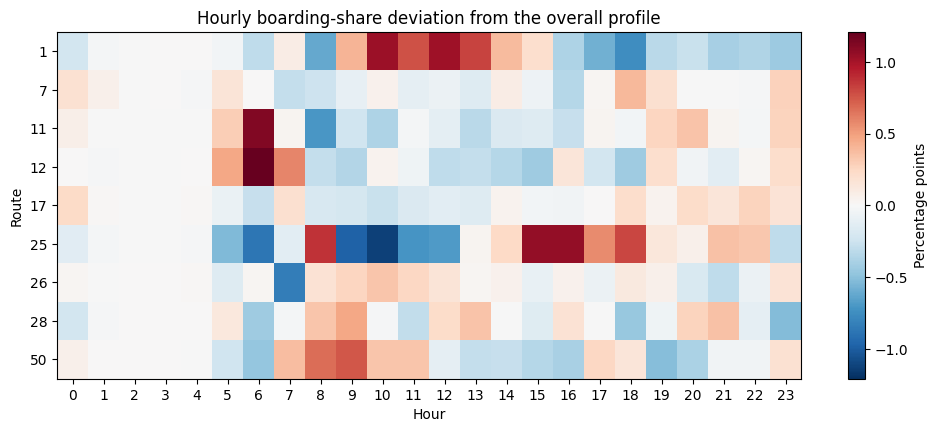

In [31]:
route_profile = shares.groupby(["route", "hour"])["share"].mean().unstack("hour")
overall_profile = shares.groupby("hour")["share"].mean()
route_delta_pp = route_profile.sub(overall_profile, axis="columns") * 100
route_distance_pp = route_delta_pp.abs().sum(axis=1) / 2
print(f"Mean route-to-overall profile distance: {route_distance_pp.mean():.2f} pp")
print(f"Range across routes: {route_distance_pp.min():.2f}–{route_distance_pp.max():.2f} pp")

fig, ax = plt.subplots(figsize=(12, 4.5))
heatmap_data = route_delta_pp.to_numpy(dtype=float)
limit = max(np.nanmax(np.abs(heatmap_data)), 0.01)
heatmap = ax.imshow(heatmap_data, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(route_profile)), labels=route_profile.index)
ax.set_xlabel("Hour")
ax.set_ylabel("Route")
ax.set_title("Hourly boarding-share deviation from the overall profile")
fig.colorbar(heatmap, ax=ax, label="Percentage points")
plt.show()

### `hour × weekend`

Средние часовые доли по всем дням маршрутов, отдельно для будней и выходных. Метрика расстояния полной вариации суммирует перераспределение суточной доли между часами; максимум абсолютного разрыва показывает самый различающийся час.

Route-days: weekdays 1557, weekends 630
Distance between profiles: 13.37 pp
Largest hourly gap: 4.87 pp at 08:00


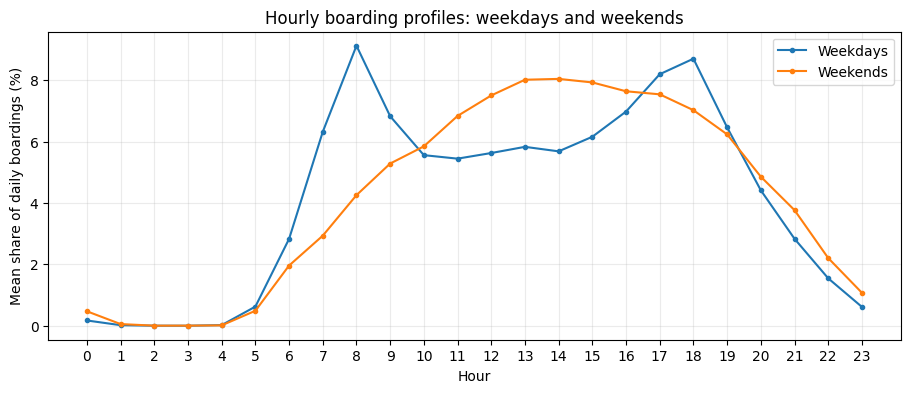

In [32]:
day_type_counts = (
    shares[["route", "date", "is_weekend"]].drop_duplicates()
    .groupby("is_weekend").size()
)
day_profile = shares.groupby(["is_weekend", "hour"])["share"].mean().unstack("hour")
assert {False, True}.issubset(day_profile.index), "Both weekdays and weekends are required"
gap_pp = (day_profile.loc[True] - day_profile.loc[False]) * 100
print(f"Route-days: weekdays {day_type_counts[False]}, weekends {day_type_counts[True]}")
print(f"Distance between profiles: {gap_pp.abs().sum() / 2:.2f} pp")
print(f"Largest hourly gap: {gap_pp.abs().max():.2f} pp at {gap_pp.abs().idxmax():02d}:00")

fig, ax = plt.subplots(figsize=(11, 4))
for is_weekend, label in [(False, "Weekdays"), (True, "Weekends")]:
    ax.plot(day_profile.columns, day_profile.loc[is_weekend] * 100, marker="o", ms=3, label=label)
ax.set_xticks(range(24))
ax.set_xlabel("Hour")
ax.set_ylabel("Mean share of daily boardings (%)")
ax.set_title("Hourly boarding profiles: weekdays and weekends")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### Conclusion

На 9 маршрутах и 243 днях (январь–август 2025; 0 дней маршрута исключено как полностью нулевые) суточные профили различаются. Среднее расстояние профиля маршрута от общего составило 2.85 п.п. и лежало в диапазоне 1.43–5.51 п.п. Различие профилей будней и выходных составило 13.37 п.п.; наибольший почасовой разрыв — 4.87 п.п. в 08:00. Эти результаты поддерживают наличие различий, описываемых взаимодействиями `route × hour` и `hour × weekend`.

### Decision

Оставить оба взаимодействия кандидатами для следующего сравнения признаков. Эти агрегированные профили сами по себе не показывают, улучшат ли взаимодействия точность прогноза; это потребует отдельной временной валидации модели.

## Feature experiment — interaction features

Сравниваем четыре варианта одной и той же модели LightGBM: текущий baseline, добавление `route × hour`, добавление `hour × weekend` и добавление обоих признаков. Во всех вариантах сохраняются baseline-признаки `route`, `weekday`, `hour`, параметры модели, seed, округление прогноза и временное разделение: обучение на январе–августе 2025, проверка на сентябре–октябре 2025.

Каждое взаимодействие кодируется отдельным категориальным признаком с фиксированным словарём категорий для train и validation. Для загрузки используются пути из `Environment & Data Setup`; CSV читаются с разделителем `;`, как в `lightgbm_baseline.py`. Фактические `boardings` валидации читаются только после получения всех прогнозов.

WAPE и `delta_WAPE_vs_baseline` выводятся как доли; отрицательная дельта означает меньшую ошибку. WAPE маршрута с нулевой суммой фактических посадок не определён и отображается как `NaN`.

In [33]:
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor

ROUTES = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)
BASELINE_FEATURES = ("route", "weekday", "hour")
EXPERIMENTS = (
    ("baseline", ()),
    ("route_hour", ("route_hour",)),
    ("hour_weekend", ("hour_weekend",)),
    ("both", ("route_hour", "hour_weekend")),
)

train = pd.read_csv(TRAIN_HOURLY_PATH, sep=";", parse_dates=["date"])
validation_keys = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["route", "date", "hour"], parse_dates=["date"]
)
if len(train) != 58_320 or len(validation_keys) != 14_640:
    raise ValueError("Unexpected hourly grid size")
if train["date"].max() >= validation_keys["date"].min():
    raise ValueError("Training and validation periods overlap")

def calendar_features(rows, added_features=()):
    features = pd.DataFrame(
        {
            "route": pd.Categorical(rows["route"], categories=ROUTES),
            "weekday": pd.Categorical(rows["date"].dt.weekday, categories=range(7)),
            "hour": pd.Categorical(rows["hour"], categories=range(24)),
        }
    )
    if "route_hour" in added_features:
        features["route_hour"] = pd.Categorical(
            rows["route"] * 24 + rows["hour"],
            categories=[route * 24 + hour for route in ROUTES for hour in range(24)],
        )
    if "hour_weekend" in added_features:
        features["hour_weekend"] = pd.Categorical(
            rows["hour"] * 2 + rows["date"].dt.weekday.ge(5).astype(int),
            categories=range(48),
        )
    return features.loc[:, list(BASELINE_FEATURES + added_features)]

In [34]:
predictions_by_experiment = {}
for experiment, added_features in EXPERIMENTS:
    feature_columns = BASELINE_FEATURES + added_features
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        calendar_features(train, added_features),
        train["boardings"],
        categorical_feature=list(feature_columns),
    )
    prediction = np.floor(
        np.maximum(model.predict(calendar_features(validation_keys, added_features)), 0) + 0.5
    )
    predictions_by_experiment[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

baseline: 14,640 validation predictions
route_hour: 14,640 validation predictions
hour_weekend: 14,640 validation predictions
both: 14,640 validation predictions


In [35]:
actual = pd.read_csv(VALID_HOURLY_PATH, sep=";", usecols=["boardings"])["boardings"].to_numpy()
if len(actual) != len(validation_keys) or actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(actual) or not np.isfinite(prediction).all()
    for prediction in predictions_by_experiment.values()
):
    raise ValueError("Invalid validation predictions")

summary_rows = []
route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
for experiment, added_features in EXPERIMENTS:
    absolute_error = np.abs(actual - predictions_by_experiment[experiment])
    summary_rows.append(
        {
            "experiment": experiment,
            "added_features": ", ".join(added_features) or "none",
            "WAPE": absolute_error.sum() / actual.sum(),
        }
    )
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    route_wape[experiment] = route_error / route_totals.replace(0, np.nan)

summary = pd.DataFrame(summary_rows)
baseline_wape = summary.loc[summary["experiment"].eq("baseline"), "WAPE"].iloc[0]
summary["delta_WAPE_vs_baseline"] = summary["WAPE"] - baseline_wape
print("Overall validation WAPE:")
display(summary.round(6))
print("WAPE by route (NaN means zero actual boardings):")
display(route_wape.reset_index().round(6))

Overall validation WAPE:


,experiment,added_features,WAPE,delta_WAPE_vs_baseline
0,baseline,none,0.132223,0.000000
1,route_hour,route_hour,0.127852,-0.004371
2,hour_weekend,hour_weekend,0.125233,-0.006990
3,both,"route_hour, hour_weekend",0.124226,-0.007997


WAPE by route (NaN means zero actual boardings):


,route,baseline,route_hour,hour_weekend,both
0,1,0.115082,0.117248,0.109434,0.109786
1,5,NaN,NaN,NaN,NaN
2,7,0.154506,0.154659,0.155729,0.157241
3,11,0.112404,0.108857,0.106732,0.106466
4,12,0.093846,0.092277,0.091424,0.088752
5,17,0.108239,0.090779,0.085868,0.086480
6,25,0.198486,0.203074,0.196006,0.198600
7,26,0.126216,0.131421,0.124021,0.127367
8,28,0.154428,0.159331,0.155350,0.154626
9,50,0.246597,0.247151,0.245962,0.240818


### Conclusion

На validation holdout overall WAPE baseline составил 0.132223. Все три варианта с interaction features дали меньший overall WAPE: `route_hour` — 0.127852 (дельта −0.004371, или −0.4371 п.п.), `hour_weekend` — 0.125233 (−0.006990, или −0.6990 п.п.), `both` — 0.124226 (−0.007997, или −0.7997 п.п.). `both` показал наименьший overall WAPE.

По сравнению с baseline WAPE улучшился на 3 из 9 маршрутов у `route_hour`, на 7 из 9 у `hour_weekend` и на 5 из 9 у `both`. У `both` ухудшение осталось на маршрутах 7, 25, 26 и 28; у `hour_weekend` — на маршрутах 7 и 28. Для маршрута 5 WAPE не определён из-за нулевой суммы фактических посадок.

### Decision

| Вариант | Решение | Основание по outputs |
|---|---|---|
| `baseline` | **KEEP** | Текущий вариант; reference WAPE = 0.132223. |
| `route_hour` | **INCONCLUSIVE** | Overall WAPE ниже baseline, но улучшение есть только на 3 из 9 маршрутов с определённым WAPE. |
| `hour_weekend` | **KEEP** | Overall WAPE ниже на 0.006990; WAPE улучшился на 7 из 9 маршрутов с определённым WAPE. |
| `both` | **KEEP** | Лучший overall WAPE (0.124226), хотя WAPE улучшился только на 5 и ухудшился на 4 из 9 маршрутов с определённым WAPE. Решение ориентировано на overall WAPE. |

Оценка относится к этому holdout; в outputs нет повторных временных срезов или оценки разброса метрик.

## Feature experiment roadmap

Инвентаризация всех кандидатов из `data/Features.md`. Статусы и результат H2 взяты из сохранённых outputs текущего notebook. Значения известны для Nov–Dec, если детерминированы ключами prediction grid или сформированы из источника, опубликованного до inference.

### A. Безопасные / известные заранее

| Кандидат — исходная гипотеза | Данные → известно на Nov–Dec? | Leakage / open-loop | Тип | Статус в notebook | Порядок |
|---|---|---|---|---|---|
| `route`, `hour`, `dow`: задают базовые различия маршрута, часа и дня недели | `route/date/hour` из grid → да | Нет; не требуется | Календарь/время, известные заранее | **KEEP** — frozen baseline | Эталон |
| `month`: сезонный дрейф | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **REJECT**: H3, WAPE 0.215877 против 0.124226 у принятой модели; хуже на 9/9 маршрутов | Проверено в H3 |
| `day`: внутримесячная динамика | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **REJECT**: H4, WAPE 0.132656 против 0.124226 у принятой модели; хуже на 9/9 маршрутов | Проверено в H4 |
| `weekofyear`: тонкая сезонная динамика | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **REJECT**: H5, WAPE 0.181815 против 0.124226 у принятой модели; хуже на 9/9 маршрутов | Проверено в H5 |
| `is_weekend`: профиль выходных отличается | `date` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H6, WAPE 0.124246 против 0.124226 у принятой модели; лучше на 4/9 и хуже на 5/9 маршрутов, флаг полностью избыточен | Проверено в H6; отдельно не добавлять |
| `is_night`: отдельный ночной режим | `hour` → да | Нет; не требуется | Календарь/время, известные заранее | **KEEP**: H7, WAPE 0.123818 против 0.124226 у принятой модели до H7; лучше на 7/9 маршрутов | Проверено в H7; включать в следующие accepted sets |
| `is_peak`: отдельный пиковый режим | `hour` → да | Нет; не требуется | Календарь/время, известные заранее | **INCONCLUSIVE**: H8, WAPE 0.123593 против 0.123818 у принятой модели; лучше на 5/9 и хуже на 4/9 маршрутов, эффект мал | Проверено в H8; не добавлять автоматически |
| `hour_sin/cos`: циклическая форма суточного профиля | `hour` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H9, WAPE 0.124243 против 0.123818 у принятой модели; хуже на 7/9 маршрутов | Проверено в H9; пару не добавлять |
| `dow_sin/cos`: циклическая форма недельного профиля | `date` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H10, WAPE 0.124615 против 0.123818 у принятой модели; хуже на 7/9 маршрутов | Проверено в H10; пару не добавлять |
| `month_sin/cos`: циклическая форма годового профиля | `date` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H11, WAPE 0.213707 против 0.123818 у принятой модели; хуже на 9/9 маршрутов | Проверено в H11; пару не добавлять |
| `hour_weekend` (`hour × weekend`): суточный профиль зависит от типа дня | `hour/date` → да | Нет; не требуется | Взаимодействие | **KEEP** — проверено моделью: WAPE 0.125233, Δ −0.006990; лучше baseline на 7/9 маршрутов с определённым WAPE | Уже проверено |
| `hour_weekend_sin/cos`: циклический профиль выходного часа | `hour/date` → да | Нет; не требуется | Взаимодействие | **REJECT** — H12: WAPE 0.124343 против 0.123818 у принятой модели; хуже на 6 из 9 маршрутов с определённой метрикой | Проверено в H12 |
| `peak_weekday`, `peak_weekend`: пик зависит от типа дня | `hour/date` → да | Нет; не требуется | Взаимодействие | **REJECT** — H13: WAPE 0.124186 против 0.123818 у принятой модели; хуже на 5 из 9 маршрутов с определённой метрикой | Проверено в H13; пару не добавлять |
| `route_hour` (`route × hour`): у маршрутов разные суточные профили | `route/hour` → да; для route 5 значение строится, но нет положительной истории для обучения его профиля | Нет; не требуется. У route 5 есть cold-start риск, не leakage | Взаимодействие | **INCONCLUSIVE** — проверено моделью: WAPE 0.127852, Δ −0.004371; лучше baseline на 3/9 маршрутов | 1: разрешить неопределённость на дополнительных temporal cutoffs |
| `route_hour_sin/cos`: циклическое кодирование route-specific профиля | `route/hour` + фиксированный `route_idx` mapping → да; route 5 остаётся cold start | Нет; не требуется. Порядок route_idx искусственный и требует проверки | Взаимодействие | **REJECT** — H14: WAPE 0.124174 против 0.123818 у принятой модели; хуже на 6 из 9 маршрутов с определённой метрикой | Проверено в H14; пару не добавлять |
| `route_dow`: реакция на день недели различается по маршрутам | `route/date` → да; route 5 остаётся cold start | Нет; не требуется | Взаимодействие | **NOT_TESTED** | 5 |
| `route_hour + hour_weekend`: совместно описывают маршрутный и недельный профили | `route/hour/date` → да | Нет; не требуется | Взаимодействие | **KEEP** — проверено моделью: лучший overall WAPE 0.124226, Δ −0.007997; лучше baseline на 5/9 маршрутов | Уже проверено; учитывать ухудшение на маршрутах 7, 25, 26, 28 |
| `days_since_start`: отражает временной дрейф | `date` и фиксированная start date → да | Нет; не требуется. Риск — экстраполяция дерева за диапазон train | Календарь/время, известные заранее (trend) | **NOT_TESTED** | 6, последним среди safe candidates |

Проверка сигнала H2 в notebook: расстояние между weekend/weekday профилями — 13.37 п.п.; максимальный почасовой разрыв — 4.87 п.п. в 08:00. Это описательный сигнал; статусы проверено моделью выше опираются на отдельный контролируемый эксперимент.

### B. Исторические / производные от target

В `data/Features.md` пока нет конкретных гипотез для исторических агрегатов или лагов и скользящих агрегатов от target. EDA и контекст прогнозирования упоминают лаги/агрегаты, но это ещё не зарегистрированные кандидаты. Перед проверкой нужно определить окно и способ построения. Источник — прошлые `boardings`; leakage возникает при использовании фактического target validation или будущего периода или глобальных агрегатов. Для validation и Nov–Dec требуется open-loop оценка: лаги/окна, попадающие внутрь прогнозного горизонта, рассчитывать рекурсивно по предыдущим predictions. Порядок — после safe calendar candidates и регистрации точной гипотезы в Features.md.

### C. Внешние / пока недоступные

| Кандидат — исходная гипотеза | Данные → известно на Nov–Dec? | Leakage / open-loop | Тип | Статус в notebook | Порядок |
|---|---|---|---|---|---|
| `is_holiday`: праздники объясняют часть провалов пассажиропотока | Официальный календарь праздников + `date` → будет известно заранее, если календарь подтверждён до inference; такого источника в текущем setup не найдено | Нет при заранее зафиксированном календаре; leakage, если метки выводить из наблюдаемого target постфактум. Open-loop не требуется | Внешние метаданные + known-in-advance calendar/time | **BLOCKED** до предоставления/подтверждения календаря | После подтверждения источника |

EDA также упоминает погоду и заранее известные изменения движения, но таких feature-кандидатов пока нет в `data/Features.md`; они не включены в эту инвентаризацию.

## H3 — month

### Hypothesis

Числовой календарный месяц может отражать медленные изменения пассажиропотока сверх принятого набора признаков `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только `date.month`.

### Availability / leakage

Месяц известен из ключа `(route, date, hour)` для всего периода Nov–Dec. Не нужны будущий target, внешние данные или рекурсия. Train охватывает январь–август, validation — сентябрь–октябрь, а inference — ноябрь–декабрь. Значения месяца на validation и inference выходят за диапазон train. Дерево LightGBM не экстраполирует тренд за обученные пороги; по одному году нельзя установить повторяющуюся годовую сезонность.


### Analysis

Используются только данные train за январь–август. Сравниваются помесячные средние посадок и средние остатки после учёта `route`, `weekday` и `hour`. Остаток служит только для описательной проверки и не становится признаком модели.


In [36]:
month_analysis = train[["route", "date", "hour", "boardings"]].copy()
month_analysis["month"] = month_analysis["date"].dt.month
month_analysis["weekday"] = month_analysis["date"].dt.weekday
context_mean = month_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
month_analysis["context_residual"] = month_analysis["boardings"] - context_mean
monthly_signal = month_analysis.groupby("month").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only monthly signal:")
display(monthly_signal.round(3))
print(
    "Range of monthly context residual means:",
    round(monthly_signal["mean_context_residual"].max()
          - monthly_signal["mean_context_residual"].min(), 3),
)


Training-only monthly signal:


,observations,mean_boardings,mean_context_residual
month,,,
1,7440,748.296,-66.877
2,6720,883.151,77.743
3,7440,903.048,111.787
4,7200,891.441,77.497
5,7440,806.575,2.846
6,7200,771.526,-27.079
7,7440,726.838,-90.084
8,7440,713.707,-76.682


Range of monthly context residual means: 201.871


### Correlation / redundancy

Для числового `month` рассчитываются Pearson и Spearman с target и описательным остатком. Число месяцев внутри каждого сочетания `route/weekday/hour` показывает структурную избыточность. Pearson для кодов категориальных признаков здесь неинформативен. Корреляция сама по себе не определяет решение о включении признака.


In [37]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"month vs {target_name}",
        "Pearson": month_analysis["month"].corr(month_analysis[target_name], method="pearson"),
        "Spearman": month_analysis["month"].corr(month_analysis[target_name], method="spearman"),
    })
print("Numeric month diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
months_per_context = month_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["month"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple months:",
    f"{months_per_context.gt(1).sum()} / {len(months_per_context)}",
)


Numeric month diagnostics on training data:


,pair,Pearson,Spearman
0,month vs boardings,-0.0428,-0.0217
1,month vs context_residual,-0.1382,-0.2178


Route/weekday/hour contexts observed in multiple months: 1680 / 1680


### LightGBM experiment

Сравниваются принятый набор и тот же набор с числовым `month`. Сохраняются frozen модель, гиперпараметры, обработка категориальных признаков, temporal split январь–август / сентябрь–октябрь, seed и постобработка прогнозов. Сначала нужно выполнить ячейки `Environment & Data Setup`, frozen baseline и setup H2. Фактический target validation читается только после построения обоих прогнозов.


In [38]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
MONTH_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_month", True),
)

def month_experiment_features(rows, add_month):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_month:
        features["month"] = rows["date"].dt.month.to_numpy(dtype="int16")
    return features

month_models = {}
month_predictions = {}
for experiment, add_month in MONTH_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        month_experiment_features(train, add_month),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(month_experiment_features(validation_keys, add_month)), 0
        ) + 0.5
    )
    month_models[experiment] = model
    month_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_month: 14,640 validation predictions


### Feature importance

Gain importance показывает, как модель с кандидатом использовала `month`. Сам по себе этот показатель не является основанием оставить признак.


In [39]:
candidate_model = month_models["current_accepted_plus_month"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("month")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:


,feature,gain,rank
3,month,68012.987,4


Top features by gain:


,feature,gain,rank
0,route_hour,2385372.568,1
1,route,561267.100,2
2,hour_weekend,526923.327,3
3,month,68012.987,4
4,weekday,29453.828,5


### Results

Для WAPE меньшее значение лучше, для WAPE-score — большее. Абсолютная и относительная дельты WAPE рассчитаны относительно текущего принятого набора; отдельная дельта — относительно исходного frozen baseline. Отрицательная дельта WAPE означает улучшение. WAPE маршрута не определён, если сумма его фактических посадок равна нулю.


In [40]:
month_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(month_actual) != len(validation_keys) or month_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(month_actual) or not np.isfinite(prediction).all()
    for prediction in month_predictions.values()
):
    raise ValueError("Invalid validation predictions")

month_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": month_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
month_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
month_result_rows = []
for experiment, add_month in MONTH_EXPERIMENTS:
    absolute_error = np.abs(month_actual - month_predictions[experiment])
    overall_wape = absolute_error.sum() / month_actual.sum()
    month_result_rows.append({
        "experiment": experiment,
        "added_features": "month" if add_month else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    month_route_wape[experiment] = route_error / month_route_totals.replace(0, np.nan)

month_results = pd.DataFrame(month_result_rows)
accepted_wape = month_results.loc[
    month_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
month_results["delta_WAPE_vs_accepted"] = month_results["WAPE"] - accepted_wape
month_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * month_results["delta_WAPE_vs_accepted"] / accepted_wape
)
month_results["delta_WAPE_vs_frozen_baseline"] = (
    month_results["WAPE"] - frozen_overall_wape
)
month_route_wape["delta_month_vs_accepted"] = (
    month_route_wape["current_accepted_plus_month"]
    - month_route_wape["current_accepted"]
)
print("Overall validation results:")
display(month_results.round(6))
print("Validation WAPE by route:")
display(month_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124226,0.875774,0.000000,0.000000,-0.007997
1,current_accepted_plus_month,month,0.215877,0.784123,0.091652,73.778238,0.083654


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_month,delta_month_vs_accepted
0,1,0.109786,0.201230,0.091444
1,5,NaN,NaN,NaN
2,7,0.157241,0.374690,0.217449
3,11,0.106466,0.170118,0.063652
4,12,0.088752,0.150549,0.061797
5,17,0.086480,0.144884,0.058404
6,25,0.198600,0.312836,0.114236
7,26,0.127367,0.260424,0.133057
8,28,0.154626,0.271345,0.116719
9,50,0.240818,0.309860,0.069042


### Conclusion

На temporal holdout за сентябрь–октябрь добавление числового `month` увеличило overall WAPE с 0.124226 до 0.215877: абсолютная дельта +0.091652, относительная +73.78%. WAPE-score снизился с 0.875774 до 0.784123. Результат кандидата выше исходного frozen baseline по WAPE на +0.083654. WAPE ухудшился на всех 9 маршрутах с определённой метрикой; для маршрута 5 знаменатель равен нулю.

На train средние помесячные остатки после учёта `route`, `weekday` и `hour` различались в диапазоне 201.871, а месяц менялся внутри всех 1680 таких сочетаний. Корреляции Pearson/Spearman с посадками были слабыми (−0.0428/−0.0217), с описательным остатком — умеренными (−0.1382/−0.2178). Gain importance составила 68012.987 (ранг 4): модель использовала признак, но качество на validation ухудшилось. Месяцы сентября–октября находились вне диапазона train, поэтому вывод относится к этому числовому кодированию и holdout.

### Decision

**REJECT** для числового `month`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`; `month` в него не добавляется.


## H4 — day

### Hypothesis

Числовой день месяца (`date.day`, 1–31) может отражать повторяющийся внутримесячный профиль спроса сверх принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только этот кандидат.

### Availability / leakage

День месяца известен из даты на всём горизонте Nov–Dec. Не нужны target, внешние данные или рекурсия. Все значения дня встречаются в train за январь–август, хотя для последних дней месяца наблюдений меньше. Target validation не используется при построении признака.


### Analysis

Используются только данные train за январь–август. Для каждого дня месяца рассматриваются средние посадки и средние остатки после учёта `route`, `weekday` и `hour`, вместе с числом наблюдений. Это проверка сигнала; описательный остаток не поступает в модель.


In [41]:
day_analysis = train[["route", "date", "hour", "boardings"]].copy()
day_analysis["day"] = day_analysis["date"].dt.day
day_analysis["weekday"] = day_analysis["date"].dt.weekday
context_mean = day_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
day_analysis["context_residual"] = day_analysis["boardings"] - context_mean
daily_signal = day_analysis.groupby("day").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only daily signal:")
display(daily_signal.round(3))
print(
    "Range of daily context residual means:",
    round(daily_signal["mean_context_residual"].max()
          - daily_signal["mean_context_residual"].min(), 3),
)


Training-only daily signal:


,observations,mean_boardings,mean_context_residual
day,,,
1,1920,619.215,-160.285
2,1920,655.240,-109.131
3,1920,795.029,-21.533
4,1920,822.739,2.760
5,1920,790.240,9.307
6,1920,772.776,-35.458
7,1920,840.614,-27.662
8,1920,666.756,-112.744
9,1920,722.328,-42.043


Range of daily context residual means: 215.162


### Correlation / redundancy

Для числового дня рассчитываются Pearson и Spearman с посадками и описательным остатком. Дополнительно подсчитывается число разных дней внутри каждого сочетания `route/weekday/hour`. Коды категориальных признаков не трактуются как непрерывные величины. Одна корреляция не определяет, включать ли признак.


In [42]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"day vs {target_name}",
        "Pearson": day_analysis["day"].corr(day_analysis[target_name], method="pearson"),
        "Spearman": day_analysis["day"].corr(day_analysis[target_name], method="spearman"),
    })
print("Numeric day diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
days_per_context = day_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["day"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple days:",
    f"{days_per_context.gt(1).sum()} / {len(days_per_context)}",
)


Numeric day diagnostics on training data:


,pair,Pearson,Spearman
0,day vs boardings,0.0409,0.0318
1,day vs context_residual,0.1311,0.1147


Route/weekday/hour contexts observed in multiple days: 1680 / 1680


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой `day`. Сохраняются frozen параметры LightGBM, обработка категориальных признаков, seed, train за январь–август, holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Target holdout читается только после завершения обоих прогнозов.


In [43]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
DAY_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_day", True),
)

def day_experiment_features(rows, add_day):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_day:
        features["day"] = rows["date"].dt.day.to_numpy(dtype="int16")
    return features

day_models = {}
day_predictions = {}
for experiment, add_day in DAY_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        day_experiment_features(train, add_day),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(day_experiment_features(validation_keys, add_day)), 0
        ) + 0.5
    )
    day_models[experiment] = model
    day_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_day: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, как модель использовала `day`; это дополнительная диагностика к temporal WAPE.


In [44]:
candidate_model = day_models["current_accepted_plus_day"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("day")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:


,feature,gain,rank
3,day,24038.92,4


Top features by gain:


,feature,gain,rank
0,route_hour,2933608.454,1
1,hour_weekend,491161.614,2
2,weekday,44698.693,3
3,day,24038.920,4
4,route,11002.358,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Если сумма фактических посадок маршрута равна нулю, его WAPE не определён.


In [45]:
day_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(day_actual) != len(validation_keys) or day_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(day_actual) or not np.isfinite(prediction).all()
    for prediction in day_predictions.values()
):
    raise ValueError("Invalid validation predictions")

day_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": day_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
day_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
day_result_rows = []
for experiment, add_day in DAY_EXPERIMENTS:
    absolute_error = np.abs(day_actual - day_predictions[experiment])
    overall_wape = absolute_error.sum() / day_actual.sum()
    day_result_rows.append({
        "experiment": experiment,
        "added_features": "day" if add_day else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    day_route_wape[experiment] = route_error / day_route_totals.replace(0, np.nan)

day_results = pd.DataFrame(day_result_rows)
accepted_wape = day_results.loc[
    day_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
day_results["delta_WAPE_vs_accepted"] = day_results["WAPE"] - accepted_wape
day_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * day_results["delta_WAPE_vs_accepted"] / accepted_wape
)
day_results["delta_WAPE_vs_frozen_baseline"] = (
    day_results["WAPE"] - frozen_overall_wape
)
day_route_wape["delta_day_vs_accepted"] = (
    day_route_wape["current_accepted_plus_day"]
    - day_route_wape["current_accepted"]
)
print("Overall validation results:")
display(day_results.round(6))
print("Validation WAPE by route:")
display(day_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124226,0.875774,0.00000,0.000000,-0.007997
1,current_accepted_plus_day,day,0.132656,0.867344,0.00843,6.786352,0.000433


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_day,delta_day_vs_accepted
0,1,0.109786,0.120110,0.010324
1,5,NaN,NaN,NaN
2,7,0.157241,0.160163,0.002923
3,11,0.106466,0.114979,0.008513
4,12,0.088752,0.098599,0.009847
5,17,0.086480,0.094525,0.008045
6,25,0.198600,0.204032,0.005431
7,26,0.127367,0.136365,0.008998
8,28,0.154626,0.163193,0.008567
9,50,0.240818,0.252661,0.011842


### Conclusion

На temporal holdout за сентябрь–октябрь добавление числового `day` увеличило overall WAPE с 0.124226 до 0.132656: абсолютная дельта +0.008430, относительная +6.79%. WAPE-score снизился с 0.875774 до 0.867344. WAPE кандидата выше исходного frozen baseline на +0.000433. WAPE ухудшился на всех 9 маршрутах с определённой метрикой; для маршрута 5 знаменатель равен нулю.

На train средние остатки по дням месяца после учёта `route`, `weekday` и `hour` различались в диапазоне 215.162; день месяца менялся внутри всех 1680 таких сочетаний. Корреляции Pearson/Spearman с посадками были слабыми (0.0409/0.0318), с описательным остатком — 0.1311/0.1147. Gain importance составила 24038.920 (ранг 4): модель использовала признак, но качество на validation ухудшилось. Это результат одного temporal holdout для числового дня месяца.

### Decision

**REJECT** для числового `day`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`; `day` в него не добавляется.


## H5 — weekofyear

### Hypothesis

Числовая ISO-неделя года (`date.isocalendar().week`) может отражать более тонкие сезонные изменения спроса сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только `weekofyear`.

### Availability / leakage

Номер ISO-недели известен из даты для всего горизонта Nov–Dec; будущий target, внешние данные и рекурсия не нужны. Train содержит январь–август, validation — сентябрь–октябрь. Все номера недель validation выходят за диапазон train; деревья LightGBM не экстраполируют временной тренд за обученные пороги. В конце декабря дата может относиться к ISO-неделе 1 следующего года, поэтому числовое кодирование имеет разрыв на границе года. Один год данных не подтверждает повторяемую сезонность.


### Analysis

Используются только данные train за январь–август. Для каждой ISO-недели рассматриваются число наблюдений, средние посадки и средние остатки после учёта `route`, `weekday` и `hour`. Это проверка наличия сигнала; описательный остаток не поступает в модель.


In [46]:
weekofyear_analysis = train[["route", "date", "hour", "boardings"]].copy()
weekofyear_analysis["weekofyear"] = weekofyear_analysis["date"].dt.isocalendar().week.astype("int16")
weekofyear_analysis["weekday"] = weekofyear_analysis["date"].dt.weekday
context_mean = weekofyear_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
weekofyear_analysis["context_residual"] = weekofyear_analysis["boardings"] - context_mean
weekly_signal = weekofyear_analysis.groupby("weekofyear").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only weekly signal:")
display(weekly_signal.round(3))
print(
    "Range of weekly context residual means:",
    round(weekly_signal["mean_context_residual"].max()
          - weekly_signal["mean_context_residual"].min(), 3),
)


Training-only weekly signal:


,observations,mean_boardings,mean_context_residual
weekofyear,,,
1,1200,412.414,-344.099
2,1680,592.944,-212.464
3,1680,866.901,61.493
4,1680,858.604,53.196
5,1680,854.764,49.356
6,1680,863.978,58.570
7,1680,891.072,85.664
8,1680,885.324,79.917
9,1680,905.117,99.709


Range of weekly context residual means: 477.837


### Correlation / redundancy

Для числового `weekofyear` рассчитываются Pearson и Spearman с посадками и описательным остатком. Дополнительно проверяется, в скольких сочетаниях `route/weekday/hour` встречается больше одной недели. Коды категориальных признаков не трактуются как непрерывные величины. Корреляция сама по себе не является правилом отбора признака.


In [47]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"weekofyear vs {target_name}",
        "Pearson": weekofyear_analysis["weekofyear"].corr(weekofyear_analysis[target_name], method="pearson"),
        "Spearman": weekofyear_analysis["weekofyear"].corr(weekofyear_analysis[target_name], method="spearman"),
    })
print("Numeric weekofyear diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
weeks_per_context = weekofyear_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["weekofyear"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple weeks:",
    f"{weeks_per_context.gt(1).sum()} / {len(weeks_per_context)}",
)


Numeric weekofyear diagnostics on training data:


,pair,Pearson,Spearman
0,weekofyear vs boardings,-0.0331,-0.0143
1,weekofyear vs context_residual,-0.1213,-0.2004


Route/weekday/hour contexts observed in multiple weeks: 1680 / 1680


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой `weekofyear`. Frozen LightGBM, гиперпараметры, обработка категориальных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов сохраняются. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [48]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
WEEKOFYEAR_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_weekofyear", True),
)

def weekofyear_experiment_features(rows, add_weekofyear):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_weekofyear:
        features["weekofyear"] = rows["date"].dt.isocalendar().week.astype("int16").to_numpy(dtype="int16")
    return features

weekofyear_models = {}
weekofyear_predictions = {}
for experiment, add_weekofyear in WEEKOFYEAR_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        weekofyear_experiment_features(train, add_weekofyear),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(weekofyear_experiment_features(validation_keys, add_weekofyear)), 0
        ) + 0.5
    )
    weekofyear_models[experiment] = model
    weekofyear_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_weekofyear: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, как модель использовала `weekofyear`. Это дополнительная диагностика, а не самостоятельное основание оставить признак.


In [49]:
candidate_model = weekofyear_models["current_accepted_plus_weekofyear"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("weekofyear")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:


,feature,gain,rank
3,weekofyear,65035.696,4


Top features by gain:


,feature,gain,rank
0,route_hour,2753397.503,1
1,hour_weekend,545975.106,2
2,route,242854.877,3
3,weekofyear,65035.696,4
4,weekday,46767.806,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [50]:
weekofyear_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(weekofyear_actual) != len(validation_keys) or weekofyear_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(weekofyear_actual) or not np.isfinite(prediction).all()
    for prediction in weekofyear_predictions.values()
):
    raise ValueError("Invalid validation predictions")

weekofyear_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": weekofyear_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
weekofyear_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
weekofyear_result_rows = []
for experiment, add_weekofyear in WEEKOFYEAR_EXPERIMENTS:
    absolute_error = np.abs(weekofyear_actual - weekofyear_predictions[experiment])
    overall_wape = absolute_error.sum() / weekofyear_actual.sum()
    weekofyear_result_rows.append({
        "experiment": experiment,
        "added_features": "weekofyear" if add_weekofyear else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    weekofyear_route_wape[experiment] = route_error / weekofyear_route_totals.replace(0, np.nan)

weekofyear_results = pd.DataFrame(weekofyear_result_rows)
accepted_wape = weekofyear_results.loc[
    weekofyear_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
weekofyear_results["delta_WAPE_vs_accepted"] = weekofyear_results["WAPE"] - accepted_wape
weekofyear_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * weekofyear_results["delta_WAPE_vs_accepted"] / accepted_wape
)
weekofyear_results["delta_WAPE_vs_frozen_baseline"] = (
    weekofyear_results["WAPE"] - frozen_overall_wape
)
weekofyear_route_wape["delta_weekofyear_vs_accepted"] = (
    weekofyear_route_wape["current_accepted_plus_weekofyear"]
    - weekofyear_route_wape["current_accepted"]
)
print("Overall validation results:")
display(weekofyear_results.round(6))
print("Validation WAPE by route:")
display(weekofyear_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124226,0.875774,0.00000,0.000000,-0.007997
1,current_accepted_plus_weekofyear,weekofyear,0.181815,0.818185,0.05759,46.358839,0.049592


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_weekofyear,delta_weekofyear_vs_accepted
0,1,0.109786,0.169106,0.059320
1,5,NaN,NaN,NaN
2,7,0.157241,0.284442,0.127201
3,11,0.106466,0.153844,0.047378
4,12,0.088752,0.129600,0.040848
5,17,0.086480,0.117598,0.031118
6,25,0.198600,0.243418,0.044818
7,26,0.127367,0.218930,0.091563
8,28,0.154626,0.211698,0.057073
9,50,0.240818,0.304019,0.063201


### Conclusion

На temporal holdout за сентябрь–октябрь добавление числового `weekofyear` увеличило overall WAPE с 0.124226 до 0.181815: абсолютная дельта +0.057590, относительная +46.36%. WAPE-score снизился с 0.875774 до 0.818185. WAPE кандидата выше исходного frozen baseline на +0.049592. WAPE ухудшился на всех 9 маршрутах с определённой метрикой; для маршрута 5 знаменатель равен нулю.

На train средние остатки по ISO-неделям после учёта `route`, `weekday` и `hour` различались в диапазоне 477.837; номер недели менялся внутри всех 1680 таких сочетаний. Корреляции Pearson/Spearman с посадками были слабыми (−0.0331/−0.0143), с описательным остатком — −0.1213/−0.2004. Gain importance составила 65035.696 (ранг 4): модель использовала признак, но качество на validation ухудшилось. Номера недель validation выходят за диапазон train; вывод относится к этому числовому кодированию и одному temporal holdout.

### Decision

**REJECT** для числового `weekofyear`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`; `weekofyear` в него не добавляется.


## H6 — is_weekend

### Hypothesis

Явный флаг выходного `is_weekend` может помочь LightGBM выделять общий эффект типа дня сверх принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Проверяется только этот бинарный признак; ранее проверенное взаимодействие остаётся в обеих версиях модели.

### Availability / leakage

Флаг однозначно определяется датой для всего горизонта Nov–Dec. Будущий target, внешние данные и рекурсия не требуются. Признак потенциально полностью избыточен по информации: он вычисляется из `weekday` и из уже принятого `hour_weekend`. Отдельное влияние на LightGBM оценивается temporal experiment, а не одной логикой признака.


### Analysis

На train за январь–август проверяются средние посадки в будни и выходные и часы с наибольшей разницей средних. Это описательная проверка сигнала, без использования target validation. Ранее в H2 уже выявлено различие суточных профилей типов дней; здесь рассматривается именно отдельный флаг.


In [51]:
weekend_analysis = train[["route", "date", "hour", "boardings"]].copy()
weekend_analysis["is_weekend"] = weekend_analysis["date"].dt.weekday.ge(5)
weekend_summary = weekend_analysis.groupby("is_weekend").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
)
print("Training-only weekday versus weekend signal:")
display(weekend_summary.round(3))

weekend_hourly = weekend_analysis.groupby(
    ["hour", "is_weekend"]
)["boardings"].mean().unstack("is_weekend")
weekend_hourly = weekend_hourly.rename(columns={False: "weekday", True: "weekend"})
weekend_hourly["weekend_minus_weekday"] = (
    weekend_hourly["weekend"] - weekend_hourly["weekday"]
)
largest_hour_gaps = weekend_hourly.loc[
    weekend_hourly["weekend_minus_weekday"].abs().nlargest(5).index
].sort_index()
print("Hours with the largest absolute mean gap:")
display(largest_hour_gaps.round(3))


Training-only weekday versus weekend signal:


,observations,mean_boardings
is_weekend,,
False,41520,914.696
True,16800,531.817


Hours with the largest absolute mean gap:


is_weekend,weekday,weekend,weekend_minus_weekday
hour,,,
7,1435.021,377.437,-1057.584
8,2009.545,529.219,-1480.326
9,1516.550,660.896,-855.655
17,1789.494,971.826,-817.668
18,1916.139,891.926,-1024.213


### Correlation / redundancy

Флаг бинарный, а принятые `weekday` и `hour_weekend` категориальные. Обычная Pearson matrix для их числовых кодов неинформативна. Вместо неё проверяется точное совпадение флага с `weekday >= 5` и с младшим битом `hour_weekend` на train. Полная информационная избыточность не заменяет проверку WAPE: явный флаг может изменить разбиения дерева.


In [52]:
accepted_train_features = calendar_features(
    train, ("route_hour", "hour_weekend")
)
weekend_flag = train["date"].dt.weekday.ge(5).astype("int8").to_numpy()
from_weekday = accepted_train_features["weekday"].astype(int).ge(5).astype("int8").to_numpy()
from_hour_weekend = (
    accepted_train_features["hour_weekend"].astype(int).mod(2).astype("int8").to_numpy()
)
print("Weekend mismatches against accepted weekday feature:", (weekend_flag != from_weekday).sum())
print(
    "Weekend mismatches against accepted hour_weekend feature:",
    (weekend_flag != from_hour_weekend).sum(),
)


Weekend mismatches against accepted weekday feature: 0
Weekend mismatches against accepted hour_weekend feature: 0


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой бинарный `is_weekend`. В обеих версиях сохраняются категориальный `hour_weekend`, frozen LightGBM, гиперпараметры, обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [53]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
IS_WEEKEND_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_is_weekend", True),
)

def is_weekend_experiment_features(rows, add_is_weekend):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_is_weekend:
        features["is_weekend"] = rows["date"].dt.weekday.ge(5).astype("int8").to_numpy(dtype="int8")
    return features

is_weekend_models = {}
is_weekend_predictions = {}
for experiment, add_is_weekend in IS_WEEKEND_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        is_weekend_experiment_features(train, add_is_weekend),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(is_weekend_experiment_features(validation_keys, add_is_weekend)), 0
        ) + 0.5
    )
    is_weekend_models[experiment] = model
    is_weekend_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_is_weekend: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, использовала ли модель добавленный `is_weekend` при уже имеющемся `hour_weekend`. Это только дополнительная диагностика к temporal WAPE.


In [54]:
candidate_model = is_weekend_models["current_accepted_plus_is_weekend"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("is_weekend")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:


,feature,gain,rank
2,is_weekend,56476.401,3


Top features by gain:


,feature,gain,rank
0,route_hour,2291035.762,1
1,hour_weekend,1145774.806,2
2,is_weekend,56476.401,3
3,hour,43031.395,4
4,route,24172.320,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [55]:
is_weekend_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(is_weekend_actual) != len(validation_keys) or is_weekend_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(is_weekend_actual) or not np.isfinite(prediction).all()
    for prediction in is_weekend_predictions.values()
):
    raise ValueError("Invalid validation predictions")

is_weekend_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": is_weekend_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
is_weekend_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
is_weekend_result_rows = []
for experiment, add_is_weekend in IS_WEEKEND_EXPERIMENTS:
    absolute_error = np.abs(is_weekend_actual - is_weekend_predictions[experiment])
    overall_wape = absolute_error.sum() / is_weekend_actual.sum()
    is_weekend_result_rows.append({
        "experiment": experiment,
        "added_features": "is_weekend" if add_is_weekend else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    is_weekend_route_wape[experiment] = route_error / is_weekend_route_totals.replace(0, np.nan)

is_weekend_results = pd.DataFrame(is_weekend_result_rows)
accepted_wape = is_weekend_results.loc[
    is_weekend_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
is_weekend_results["delta_WAPE_vs_accepted"] = is_weekend_results["WAPE"] - accepted_wape
is_weekend_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * is_weekend_results["delta_WAPE_vs_accepted"] / accepted_wape
)
is_weekend_results["delta_WAPE_vs_frozen_baseline"] = (
    is_weekend_results["WAPE"] - frozen_overall_wape
)
is_weekend_route_wape["delta_is_weekend_vs_accepted"] = (
    is_weekend_route_wape["current_accepted_plus_is_weekend"]
    - is_weekend_route_wape["current_accepted"]
)
print("Overall validation results:")
display(is_weekend_results.round(6))
print("Validation WAPE by route:")
display(is_weekend_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124226,0.875774,0.00000,0.000000,-0.007997
1,current_accepted_plus_is_weekend,is_weekend,0.124246,0.875754,0.00002,0.015905,-0.007978


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_is_weekend,delta_is_weekend_vs_accepted
0,1,0.109786,0.109561,-0.000224
1,5,NaN,NaN,NaN
2,7,0.157241,0.158051,0.000810
3,11,0.106466,0.107306,0.000840
4,12,0.088752,0.088969,0.000216
5,17,0.086480,0.085441,-0.001039
6,25,0.198600,0.197685,-0.000915
7,26,0.127367,0.127851,0.000484
8,28,0.154626,0.154417,-0.000209
9,50,0.240818,0.241357,0.000539


### Conclusion

На temporal holdout за сентябрь–октябрь добавление бинарного `is_weekend` повысило overall WAPE с 0.124226 до 0.124246: абсолютная дельта +0.000020, относительная +0.015905%. WAPE-score снизился с 0.875774 до 0.875754. По отношению к исходному frozen baseline добавленный вариант всё ещё лучше на 0.007978 WAPE, но хуже текущего принятого набора. WAPE улучшился на 4 маршрутах и ухудшился на 5; для маршрута 5 метрика не определена из-за нулевой суммы фактических посадок.

На train средние посадки в будни и выходные различались (914.696 против 531.817); максимальный почасовой разрыв был в 08:00 (−1480.326 в выходные). Но флаг полностью восстанавливается как из `weekday`, так и из `hour_weekend` — по 0 несовпадений. Pearson для кодов этих категориальных признаков неинформативен. Gain importance флага составила 56476.401 (ранг 3): модель использовала его, но отдельного выигрыша по overall WAPE не получила. Разница WAPE очень мала и не доказывает устойчивого вреда; сохранённый temporal experiment не даёт основания добавлять избыточный признак.

### Decision

**REJECT** отдельное добавление `is_weekend` к текущему принятому набору. Принятыми остаются `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Тип дня продолжает использоваться внутри принятого взаимодействия `hour_weekend`.


## H7 — is_night

### Hypothesis

Явный флаг ночных часов `is_night` (00:00–05:00) может помочь LightGBM выделять ночной режим сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Проверяется только этот флаг; граница ночи зафиксирована в `data/Features.md` до эксперимента.

### Availability / leakage

Флаг однозначно определяется значением `hour` из prediction grid на всём горизонте Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Информация уже содержится в категориальных `hour` и `route_hour`; отдельный флаг может лишь изменить удобство разбиения дерева. Его пользу определяет temporal WAPE.


### Analysis

На train за январь–август сравниваются число наблюдений, средние посадки и доля всех посадок для ночных и остальных часов. Это описательная проверка сигнала без target validation; различие уровней само по себе не подтверждает пользу нового признака при уже принятом `hour`.


In [56]:
night_analysis = train[["hour", "boardings"]].copy()
night_analysis["is_night"] = night_analysis["hour"].between(0, 5)
night_summary = night_analysis.groupby("is_night").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    total_boardings=("boardings", "sum"),
)
night_summary["share_of_total"] = (
    night_summary["total_boardings"] / night_summary["total_boardings"].sum()
)
print("Training-only night versus other hours:")
display(night_summary.round(4))


Training-only night versus other hours:


,observations,mean_boardings,total_boardings,share_of_total
is_night,,,,
False,43740,1062.2803,46464139,0.9904
True,14580,30.7662,448571,0.0096


### Correlation / redundancy

Флаг бинарный, а принятые `hour` и `route_hour` категориальные. Pearson для их числовых кодов неинформативен. Вместо него проверяется точное совпадение `is_night` с индикатором часов 0–5, восстановленным из каждого принятого признака. Полная информационная избыточность не заменяет контролируемое сравнение WAPE.


In [57]:
accepted_train_features = calendar_features(
    train, ("route_hour", "hour_weekend")
)
night_flag = train["hour"].between(0, 5).astype("int8").to_numpy()
from_hour = accepted_train_features["hour"].astype(int).between(0, 5).astype("int8").to_numpy()
from_route_hour = (
    accepted_train_features["route_hour"].astype(int).mod(24)
    .between(0, 5).astype("int8").to_numpy()
)
print("Night mismatches against accepted hour feature:", (night_flag != from_hour).sum())
print(
    "Night mismatches against accepted route_hour feature:",
    (night_flag != from_route_hour).sum(),
)


Night mismatches against accepted hour feature: 0
Night mismatches against accepted route_hour feature: 0


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой бинарный `is_night`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, обработка категориальных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [58]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
IS_NIGHT_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_is_night", True),
)

def is_night_experiment_features(rows, add_is_night):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_is_night:
        features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    return features

is_night_models = {}
is_night_predictions = {}
for experiment, add_is_night in IS_NIGHT_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        is_night_experiment_features(train, add_is_night),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(is_night_experiment_features(validation_keys, add_is_night)), 0
        ) + 0.5
    )
    is_night_models[experiment] = model
    is_night_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_is_night: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, использовала ли модель добавленный `is_night` при уже имеющихся `hour` и `route_hour`. Это дополнительная диагностика к temporal WAPE.


In [59]:
candidate_model = is_night_models["current_accepted_plus_is_night"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("is_night")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:


,feature,gain,rank
2,is_night,30845.364,3


Top features by gain:


,feature,gain,rank
0,route_hour,2560333.957,1
1,hour_weekend,559500.942,2
2,is_night,30845.364,3
3,weekday,24539.034,4
4,route,13226.341,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [60]:
is_night_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(is_night_actual) != len(validation_keys) or is_night_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(is_night_actual) or not np.isfinite(prediction).all()
    for prediction in is_night_predictions.values()
):
    raise ValueError("Invalid validation predictions")

is_night_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": is_night_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
is_night_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
is_night_result_rows = []
for experiment, add_is_night in IS_NIGHT_EXPERIMENTS:
    absolute_error = np.abs(is_night_actual - is_night_predictions[experiment])
    overall_wape = absolute_error.sum() / is_night_actual.sum()
    is_night_result_rows.append({
        "experiment": experiment,
        "added_features": "is_night" if add_is_night else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    is_night_route_wape[experiment] = route_error / is_night_route_totals.replace(0, np.nan)

is_night_results = pd.DataFrame(is_night_result_rows)
accepted_wape = is_night_results.loc[
    is_night_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
is_night_results["delta_WAPE_vs_accepted"] = is_night_results["WAPE"] - accepted_wape
is_night_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * is_night_results["delta_WAPE_vs_accepted"] / accepted_wape
)
is_night_results["delta_WAPE_vs_frozen_baseline"] = (
    is_night_results["WAPE"] - frozen_overall_wape
)
is_night_route_wape["delta_is_night_vs_accepted"] = (
    is_night_route_wape["current_accepted_plus_is_night"]
    - is_night_route_wape["current_accepted"]
)
print("Overall validation results:")
display(is_night_results.round(6))
print("Validation WAPE by route:")
display(is_night_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124226,0.875774,0.000000,0.000000,-0.007997
1,current_accepted_plus_is_night,is_night,0.123818,0.876182,-0.000408,-0.328585,-0.008406


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_is_night,delta_is_night_vs_accepted
0,1,0.109786,0.109409,-0.000377
1,5,NaN,NaN,NaN
2,7,0.157241,0.157384,0.000143
3,11,0.106466,0.105465,-0.001001
4,12,0.088752,0.088093,-0.000659
5,17,0.086480,0.085936,-0.000544
6,25,0.198600,0.199601,0.001001
7,26,0.127367,0.125405,-0.001963
8,28,0.154626,0.153737,-0.000888
9,50,0.240818,0.240671,-0.000147


### Conclusion

На temporal holdout за сентябрь–октябрь добавление бинарного `is_night` снизило overall WAPE с 0.124226 до 0.123818: абсолютная дельта −0.000408, относительная −0.328585%. WAPE-score вырос с 0.875774 до 0.876182. Относительно исходного frozen baseline WAPE нового варианта ниже на 0.008406. WAPE улучшился на 7 маршрутах и ухудшился на 2 (7 и 25); для маршрута 5 метрика не определена из-за нулевой суммы фактических посадок.

На train ночные часы имели средние 30.7662 посадки против 1062.2803 в остальные часы и составляли 0.96% всех посадок. Флаг полностью восстанавливается из `hour` и `route_hour` — по 0 несовпадений; Pearson для их категориальных кодов неинформативен. Gain importance флага составила 30845.364 (ранг 3), что показывает использование моделью, но не служит отдельным доказательством полезности. Улучшение WAPE небольшое и получено на одном temporal holdout; устойчивость на других временных срезах пока неизвестна.

### Decision

**KEEP** `is_night` для текущего последовательного набора: overall WAPE ниже и 7 из 9 маршрутов с определённой метрикой улучшились. Следующие feature experiments должны сравнивать кандидатов с принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`.


## H8 — is_peak

### Hypothesis

Явный флаг часов пик `is_peak` (07:00, 08:00, 09:00, 17:00, 18:00, 19:00) может помочь LightGBM выделять пиковый режим сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend` и `is_night`. Проверяется только этот флаг; часы пик зафиксированы в `data/Features.md` до эксперимента.

### Availability / leakage

Флаг однозначно определяется значением `hour` из prediction grid на всём горизонте Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Информация уже содержится в категориальных `hour` и `route_hour`; дополнительный флаг проверяется на том же temporal holdout, что и текущий принятый набор.


### Analysis

На train за январь–август сравниваются число наблюдений, средние посадки и доля всех посадок для фиксированных пиковых и остальных часов. Отдельная небольшая таблица показывает средние по типу дня, чтобы проверить, не скрывает ли общий итог разные режимы будней и выходных. Это описательная проверка без target validation.


In [61]:
peak_analysis = train[["date", "hour", "boardings"]].copy()
peak_analysis["is_peak"] = peak_analysis["hour"].isin((7, 8, 9, 17, 18, 19))
peak_analysis["is_weekend"] = peak_analysis["date"].dt.weekday.ge(5)
peak_summary = peak_analysis.groupby("is_peak").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    total_boardings=("boardings", "sum"),
)
peak_summary["share_of_total"] = (
    peak_summary["total_boardings"] / peak_summary["total_boardings"].sum()
)
print("Training-only peak versus other hours:")
display(peak_summary.round(4))
print("Mean boardings by peak and day type:")
display(
    peak_analysis.groupby(["is_weekend", "is_peak"])["boardings"]
    .mean().rename("mean_boardings").reset_index().round(3)
)


Training-only peak versus other hours:


,observations,mean_boardings,total_boardings,share_of_total
is_peak,,,,
False,43740,605.9225,26503049,0.5649
True,14580,1399.8396,20409661,0.4351


Mean boardings by peak and day type:


,is_weekend,is_peak,mean_boardings
0,False,False,659.159
1,False,True,1681.309
2,True,False,474.353
3,True,True,704.208


### Correlation / redundancy

Флаг бинарный, а принятые `hour` и `route_hour` категориальные. Pearson для их числовых кодов неинформативен. Вместо него проверяется точное совпадение `is_peak` с индикатором заранее выбранных часов, восстановленным из каждого принятого признака. Дополнительно проверяется пересечение с принятым `is_night`. Информационная избыточность сама по себе не заменяет сравнение WAPE.


In [62]:
accepted_train_features = calendar_features(
    train, ("route_hour", "hour_weekend")
)
peak_hours = (7, 8, 9, 17, 18, 19)
peak_flag = train["hour"].isin(peak_hours).astype("int8").to_numpy()
from_hour = accepted_train_features["hour"].astype(int).isin(peak_hours).astype("int8").to_numpy()
from_route_hour = (
    accepted_train_features["route_hour"].astype(int).mod(24)
    .isin(peak_hours).astype("int8").to_numpy()
)
night_flag = train["hour"].between(0, 5).astype("int8").to_numpy()
print("Peak mismatches against accepted hour feature:", (peak_flag != from_hour).sum())
print(
    "Peak mismatches against accepted route_hour feature:",
    (peak_flag != from_route_hour).sum(),
)
print("Peak/night overlap rows:", (peak_flag & night_flag).sum())


Peak mismatches against accepted hour feature: 0
Peak mismatches against accepted route_hour feature: 0
Peak/night overlap rows: 0


### LightGBM experiment

Сравниваются текущий принятый набор, включая `is_night`, и тот же набор плюс числовой бинарный `is_peak`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [63]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
PEAK_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_is_peak", True),
)

def peak_experiment_features(rows, add_is_peak):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_is_peak:
        features["is_peak"] = (
            rows["hour"].isin((7, 8, 9, 17, 18, 19))
            .astype("int8").to_numpy(dtype="int8")
        )
    return features

peak_models = {}
peak_predictions = {}
for experiment, add_is_peak in PEAK_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        peak_experiment_features(train, add_is_peak),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(peak_experiment_features(validation_keys, add_is_peak)), 0
        ) + 0.5
    )
    peak_models[experiment] = model
    peak_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_is_peak: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, использовала ли модель добавленный `is_peak` при уже имеющихся `hour`, `route_hour` и `is_night`. Это дополнительная диагностика к temporal WAPE.


In [64]:
candidate_model = peak_models["current_accepted_plus_is_peak"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("is_peak")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:


,feature,gain,rank
6,is_peak,95.608,7


Top features by gain:


,feature,gain,rank
0,route_hour,2648592.177,1
1,hour_weekend,490729.034,2
2,weekday,16942.964,3
3,route,6919.427,4
4,is_night,1190.160,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [65]:
peak_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(peak_actual) != len(validation_keys) or peak_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(peak_actual) or not np.isfinite(prediction).all()
    for prediction in peak_predictions.values()
):
    raise ValueError("Invalid validation predictions")

peak_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": peak_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
peak_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
peak_result_rows = []
for experiment, add_is_peak in PEAK_EXPERIMENTS:
    absolute_error = np.abs(peak_actual - peak_predictions[experiment])
    overall_wape = absolute_error.sum() / peak_actual.sum()
    peak_result_rows.append({
        "experiment": experiment,
        "added_features": "is_peak" if add_is_peak else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    peak_route_wape[experiment] = route_error / peak_route_totals.replace(0, np.nan)

peak_results = pd.DataFrame(peak_result_rows)
accepted_wape = peak_results.loc[
    peak_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
peak_results["delta_WAPE_vs_accepted"] = peak_results["WAPE"] - accepted_wape
peak_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * peak_results["delta_WAPE_vs_accepted"] / accepted_wape
)
peak_results["delta_WAPE_vs_frozen_baseline"] = (
    peak_results["WAPE"] - frozen_overall_wape
)
peak_route_wape["delta_is_peak_vs_accepted"] = (
    peak_route_wape["current_accepted_plus_is_peak"]
    - peak_route_wape["current_accepted"]
)
print("Overall validation results:")
display(peak_results.round(6))
print("Validation WAPE by route:")
display(peak_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123818,0.876182,0.000000,0.000000,-0.008406
1,current_accepted_plus_is_peak,is_peak,0.123593,0.876407,-0.000225,-0.181552,-0.008630


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_is_peak,delta_is_peak_vs_accepted
0,1,0.109409,0.109458,0.000048
1,5,NaN,NaN,NaN
2,7,0.157384,0.156675,-0.000709
3,11,0.105465,0.106330,0.000865
4,12,0.088093,0.087609,-0.000484
5,17,0.085936,0.084496,-0.001440
6,25,0.199601,0.199586,-0.000015
7,26,0.125405,0.127195,0.001790
8,28,0.153737,0.153852,0.000115
9,50,0.240671,0.240329,-0.000342


### Conclusion

На temporal holdout за сентябрь–октябрь добавление бинарного `is_peak` к принятому набору с `is_night` снизило overall WAPE с 0.123818 до 0.123593: абсолютная дельта −0.000225, относительная −0.181552%. WAPE-score вырос с 0.876182 до 0.876407; относительно исходного frozen baseline WAPE нового варианта ниже на 0.008630. WAPE улучшился на 5 маршрутах и ухудшился на 4; для маршрута 5 метрика не определена из-за нулевой суммы фактических посадок. Наибольшее маршрутное ухудшение в сохранённой таблице — у маршрута 26 (+0.001790).

На train пиковые часы имели средние 1399.8396 посадки против 605.9225 в остальные часы и дали 43.51% посадок. Флаг полностью восстанавливается из `hour` и `route_hour` — по 0 несовпадений; с `is_night` пересечений нет. Pearson для категориальных кодов неинформативен. Gain importance флага составила 95.608 (ранг 7): модель использовала его с небольшим gain, но этот показатель не определяет решение. Улучшение overall WAPE мало и получено на одном holdout при смешанной картине по маршрутам; устойчивый вклад отдельного флага пока не установлен.

### Decision

**INCONCLUSIVE** для отдельного `is_peak`. Не добавлять его автоматически в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Если возвращаться к флагу, потребуется дополнительная temporal проверка на тех же правилах сравнения.


## H9 — hour_sin / hour_cos

### Hypothesis

Парное циклическое кодирование часа `hour_sin = sin(2π · hour / 24)` и `hour_cos = cos(2π · hour / 24)` может помочь LightGBM учитывать близость часов 23:00 и 00:00 и гладкую форму суточного профиля. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе как одна связанная feature group; циклические признаки дня недели и месяца сейчас не проверяются.

### Availability / leakage

Час известен из prediction grid на всём горизонте Nov–Dec; будущий target, внешние данные и рекурсия не нужны. Пара `hour_sin/hour_cos` однозначно вычисляется из уже принятого категориального `hour`, поэтому новых сведений о наблюдении не добавляет. Эксперимент проверяет, помогает ли эта форма представления тому же LightGBM pipeline.


### Analysis

На train за январь–август проверяется среднее число посадок по каждому часу и разница между соседними часами, включая границу 23:00 → 00:00. Это описание суточного сигнала; target validation не используется. Наличие суточного профиля само по себе не доказывает пользу его дополнительного кодирования.


In [66]:
hour_profile = (
    train.groupby("hour")["boardings"]
    .agg(observations="size", mean_boardings="mean")
    .reindex(range(24))
)
hour_profile["gap_from_previous_hour"] = np.abs(
    hour_profile["mean_boardings"].to_numpy()
    - np.roll(hour_profile["mean_boardings"].to_numpy(), 1)
)
print("Training-only hourly profile:")
display(hour_profile.round(3))
print(
    "23:00 to 00:00 mean gap:",
    round(hour_profile.loc[0, "gap_from_previous_hour"], 3),
)
print(
    "Median adjacent-hour mean gap:",
    round(hour_profile["gap_from_previous_hour"].median(), 3),
)


Training-only hourly profile:


,observations,mean_boardings,gap_from_previous_hour
hour,,,
0,2430,48.342,102.384
1,2430,5.137,43.205
2,2430,0.214,4.923
3,2430,0.263,0.049
4,2430,4.329,4.065
5,2430,126.311,121.982
6,2430,546.733,420.422
7,2430,1130.367,583.634
8,2430,1583.113,452.746


23:00 to 00:00 mean gap: 102.384
Median adjacent-hour mean gap: 120.7


### Correlation / redundancy

Для числовых `hour_sin` и `hour_cos` рассчитываются Pearson и Spearman с посадками на train. Каждый компонент отдельно не задаёт положение на окружности, поэтому эти корреляции лишь диагностические. Для категориального `hour` Pearson по кодам не применяется. Дополнительно проверяется, что обе координаты точно восстанавливаются из принятого `hour` и что каждому из 24 часов соответствует своя пара.


In [67]:
hour_values = train["hour"].to_numpy(dtype=float)
hour_angle = 2 * np.pi * hour_values / 24
hour_sin = np.sin(hour_angle)
hour_cos = np.cos(hour_angle)
cycle_correlations = []
for feature_name, values in (("hour_sin", hour_sin), ("hour_cos", hour_cos)):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_vs_boardings": feature_series.corr(train["boardings"], method="pearson"),
        "Spearman_vs_boardings": feature_series.corr(train["boardings"], method="spearman"),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))

accepted_hour = calendar_features(
    train, ("route_hour", "hour_weekend")
)["hour"].astype(int).to_numpy()
accepted_angle = 2 * np.pi * accepted_hour / 24
print(
    "Maximum absolute difference reconstructed from accepted hour:",
    max(
        np.max(np.abs(hour_sin - np.sin(accepted_angle))),
        np.max(np.abs(hour_cos - np.cos(accepted_angle))),
    ),
)
print(
    "Distinct rounded (sin, cos) pairs for 24 hours:",
    np.unique(
        np.round(
            np.column_stack((
                np.sin(2 * np.pi * np.arange(24) / 24),
                np.cos(2 * np.pi * np.arange(24) / 24),
            )),
            12,
        ),
        axis=0,
    ).shape[0],
)


Training-only numeric diagnostics:


,feature,Pearson_vs_boardings,Spearman_vs_boardings
0,hour_sin,-0.2324,-0.2656
1,hour_cos,-0.4711,-0.5597


Maximum absolute difference reconstructed from accepted hour: 0.0
Distinct rounded (sin, cos) pairs for 24 hours: 24


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `hour_sin/hour_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [68]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
HOUR_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_hour_cycle", True),
)

def hour_cycle_features(rows, add_hour_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_hour_cycle:
        angle = 2 * np.pi * rows["hour"].to_numpy(dtype=float) / 24
        features["hour_sin"] = np.sin(angle)
        features["hour_cos"] = np.cos(angle)
    return features

hour_cycle_models = {}
hour_cycle_predictions = {}
for experiment, add_hour_cycle in HOUR_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        hour_cycle_features(train, add_hour_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(hour_cycle_features(validation_keys, add_hour_cycle)), 0
        ) + 0.5
    )
    hour_cycle_models[experiment] = model
    hour_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_hour_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих новых компонентов; также выводится их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [69]:
candidate_model = hour_cycle_models["current_accepted_plus_hour_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("hour_sin", "hour_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:


,feature,gain,rank
5,hour_sin,5330.550,6
7,hour_cos,570.745,8


Combined candidate gain: 5901.295
Top features by gain:


,feature,gain,rank
0,route_hour,2604624.239,1
1,hour_weekend,488604.016,2
2,weekday,38005.739,3
3,route,25600.776,4
4,hour,5536.695,5
5,hour_sin,5330.550,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [70]:
hour_cycle_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(hour_cycle_actual) != len(validation_keys) or hour_cycle_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(hour_cycle_actual) or not np.isfinite(prediction).all()
    for prediction in hour_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

hour_cycle_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": hour_cycle_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
hour_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
hour_cycle_result_rows = []
for experiment, add_hour_cycle in HOUR_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(hour_cycle_actual - hour_cycle_predictions[experiment])
    overall_wape = absolute_error.sum() / hour_cycle_actual.sum()
    hour_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": "hour_sin, hour_cos" if add_hour_cycle else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    hour_cycle_route_wape[experiment] = route_error / hour_cycle_route_totals.replace(0, np.nan)

hour_cycle_results = pd.DataFrame(hour_cycle_result_rows)
accepted_wape = hour_cycle_results.loc[
    hour_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
hour_cycle_results["delta_WAPE_vs_accepted"] = hour_cycle_results["WAPE"] - accepted_wape
hour_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * hour_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
hour_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    hour_cycle_results["WAPE"] - frozen_overall_wape
)
hour_cycle_route_wape["delta_hour_cycle_vs_accepted"] = (
    hour_cycle_route_wape["current_accepted_plus_hour_cycle"]
    - hour_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(hour_cycle_results.round(6))
print("Validation WAPE by route:")
display(hour_cycle_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123818,0.876182,0.000000,0.000000,-0.008406
1,current_accepted_plus_hour_cycle,"hour_sin, hour_cos",0.124243,0.875757,0.000426,0.343916,-0.007980


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_hour_cycle,delta_hour_cycle_vs_accepted
0,1,0.109409,0.109777,0.000368
1,5,NaN,NaN,NaN
2,7,0.157384,0.157063,-0.000321
3,11,0.105465,0.106142,0.000677
4,12,0.088093,0.088291,0.000198
5,17,0.085936,0.086296,0.000359
6,25,0.199601,0.199011,-0.000590
7,26,0.125405,0.126662,0.001257
8,28,0.153737,0.154108,0.000370
9,50,0.240671,0.241844,0.001172


### Conclusion

На temporal holdout за сентябрь–октябрь совместное добавление `hour_sin` и `hour_cos` повысило overall WAPE с 0.123818 до 0.124243: сохранённая абсолютная дельта +0.000426, относительная +0.343916%. WAPE-score снизился с 0.876182 до 0.875757. Относительно исходного frozen baseline WAPE нового варианта ниже на 0.007980, но выше текущего принятого набора. WAPE улучшился на 2 маршрутах (7, 25) и ухудшился на 7; для маршрута 5 метрика не определена из-за нулевой суммы фактических посадок.

На train был выраженный суточный профиль; средний разрыв 23:00 → 00:00 составил 102.384 посадки при медиане соседних разрывов 120.7. Pearson/Spearman с посадками составили −0.2324/−0.2656 для `hour_sin` и −0.4711/−0.5597 для `hour_cos`. Пара точно восстанавливается из принятого `hour` и даёт 24 разные пары для 24 часов; корреляции не служат правилом отбора. Gain importance составила 5330.550 (ранг 6) и 570.745 (ранг 8), суммарно 5901.295: это дополнительная диагностика, а не доказательство пользы. На данном temporal holdout добавление пары не помогло.

### Decision

**REJECT** совместное добавление `hour_sin` и `hour_cos`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Вывод относится к этой паре; другие циклические признаки не оценивались.


## H10 — dow_sin / dow_cos

### Hypothesis

Парное циклическое кодирование дня недели `dow_sin = sin(2π · dow / 7)` и `dow_cos = cos(2π · dow / 7)` может помочь LightGBM учитывать близость воскресенья и понедельника и форму недельного профиля. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе; циклический месяц сейчас не проверяется.

### Availability / leakage

День недели вычисляется из даты prediction grid для всего горизонта Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Пара `dow_sin/dow_cos` точно определяется уже принятым категориальным `weekday` и не добавляет новых сведений; temporal experiment проверяет влияние формы представления на тот же LightGBM pipeline.


### Analysis

На train за январь–август проверяются средние посадки по дням недели и разница между соседними днями, включая границу воскресенье → понедельник. Это описательный недельный сигнал без target validation. Наличие различий не доказывает пользу дополнительного кодирования.


In [72]:
dow_profile = (
    train.assign(weekday=train["date"].dt.weekday)
    .groupby("weekday")["boardings"]
    .agg(observations="size", mean_boardings="mean")
    .reindex(range(7))
)
dow_profile["gap_from_previous_day"] = np.abs(
    dow_profile["mean_boardings"].to_numpy()
    - np.roll(dow_profile["mean_boardings"].to_numpy(), 1)
)
print("Training-only day-of-week profile (Monday=0):")
display(dow_profile.round(3))
print(
    "Sunday to Monday mean gap:",
    round(dow_profile.loc[0, "gap_from_previous_day"], 3),
)
print(
    "Median adjacent-day mean gap:",
    round(dow_profile["gap_from_previous_day"].median(), 3),
)


Training-only day-of-week profile (Monday=0):


,observations,mean_boardings,gap_from_previous_day
weekday,,,
0,8160,914.043,421.350
1,8160,941.248,27.205
2,8400,925.667,15.581
3,8400,906.267,19.401
4,8400,886.996,19.270
5,8400,570.940,316.056
6,8400,492.693,78.247


Sunday to Monday mean gap: 421.35
Median adjacent-day mean gap: 27.205


### Correlation / redundancy

Для числовых `dow_sin` и `dow_cos` рассчитываются Pearson и Spearman с посадками на train; каждый компонент по отдельности не задаёт день на окружности, поэтому это лишь диагностика. Pearson для кодов категориального `weekday` не применяется. Дополнительно проверяется точное восстановление обеих координат из принятого `weekday` и уникальность пары для каждого из семи дней.


In [73]:
dow_values = train["date"].dt.weekday.to_numpy(dtype=float)
dow_angle = 2 * np.pi * dow_values / 7
dow_sin = np.sin(dow_angle)
dow_cos = np.cos(dow_angle)
cycle_correlations = []
for feature_name, values in (("dow_sin", dow_sin), ("dow_cos", dow_cos)):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_vs_boardings": feature_series.corr(train["boardings"], method="pearson"),
        "Spearman_vs_boardings": feature_series.corr(train["boardings"], method="spearman"),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))

accepted_dow = calendar_features(
    train, ("route_hour", "hour_weekend")
)["weekday"].astype(int).to_numpy()
accepted_angle = 2 * np.pi * accepted_dow / 7
print(
    "Maximum absolute difference reconstructed from accepted weekday:",
    max(
        np.max(np.abs(dow_sin - np.sin(accepted_angle))),
        np.max(np.abs(dow_cos - np.cos(accepted_angle))),
    ),
)
print(
    "Distinct rounded (sin, cos) pairs for 7 weekdays:",
    np.unique(
        np.round(
            np.column_stack((
                np.sin(2 * np.pi * np.arange(7) / 7),
                np.cos(2 * np.pi * np.arange(7) / 7),
            )),
            12,
        ),
        axis=0,
    ).shape[0],
)


Training-only numeric diagnostics:


,feature,Pearson_vs_boardings,Spearman_vs_boardings
0,dow_sin,0.1507,0.1047
1,dow_cos,-0.0315,0.0012


Maximum absolute difference reconstructed from accepted weekday: 0.0
Distinct rounded (sin, cos) pairs for 7 weekdays: 7


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `dow_sin/dow_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [74]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
DOW_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_dow_cycle", True),
)

def dow_cycle_features(rows, add_dow_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_dow_cycle:
        angle = 2 * np.pi * rows["date"].dt.weekday.to_numpy(dtype=float) / 7
        features["dow_sin"] = np.sin(angle)
        features["dow_cos"] = np.cos(angle)
    return features

dow_cycle_models = {}
dow_cycle_predictions = {}
for experiment, add_dow_cycle in DOW_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        dow_cycle_features(train, add_dow_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(dow_cycle_features(validation_keys, add_dow_cycle)), 0
        ) + 0.5
    )
    dow_cycle_models[experiment] = model
    dow_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_dow_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих новых компонентов; также выводится их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [75]:
candidate_model = dow_cycle_models["current_accepted_plus_dow_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("dow_sin", "dow_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:


,feature,gain,rank
2,dow_cos,23268.396,3
3,dow_sin,12856.548,4


Combined candidate gain: 36124.944
Top features by gain:


,feature,gain,rank
0,route_hour,2824458.480,1
1,hour_weekend,490810.473,2
2,dow_cos,23268.396,3
3,dow_sin,12856.548,4
4,route,11392.884,5
5,weekday,8333.486,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [76]:
dow_cycle_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(dow_cycle_actual) != len(validation_keys) or dow_cycle_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(dow_cycle_actual) or not np.isfinite(prediction).all()
    for prediction in dow_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

dow_cycle_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": dow_cycle_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
dow_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
dow_cycle_result_rows = []
for experiment, add_dow_cycle in DOW_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(dow_cycle_actual - dow_cycle_predictions[experiment])
    overall_wape = absolute_error.sum() / dow_cycle_actual.sum()
    dow_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": "dow_sin, dow_cos" if add_dow_cycle else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    dow_cycle_route_wape[experiment] = route_error / dow_cycle_route_totals.replace(0, np.nan)

dow_cycle_results = pd.DataFrame(dow_cycle_result_rows)
accepted_wape = dow_cycle_results.loc[
    dow_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
dow_cycle_results["delta_WAPE_vs_accepted"] = dow_cycle_results["WAPE"] - accepted_wape
dow_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * dow_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
dow_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    dow_cycle_results["WAPE"] - frozen_overall_wape
)
dow_cycle_route_wape["delta_dow_cycle_vs_accepted"] = (
    dow_cycle_route_wape["current_accepted_plus_dow_cycle"]
    - dow_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(dow_cycle_results.round(6))
print("Validation WAPE by route:")
display(dow_cycle_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123818,0.876182,0.000000,0.000000,-0.008406
1,current_accepted_plus_dow_cycle,"dow_sin, dow_cos",0.124615,0.875385,0.000798,0.644265,-0.007608


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_dow_cycle,delta_dow_cycle_vs_accepted
0,1,0.109409,0.111248,0.001839
1,5,NaN,NaN,NaN
2,7,0.157384,0.155510,-0.001874
3,11,0.105465,0.106833,0.001368
4,12,0.088093,0.089684,0.001591
5,17,0.085936,0.086872,0.000936
6,25,0.199601,0.197468,-0.002133
7,26,0.125405,0.128818,0.003413
8,28,0.153737,0.154666,0.000928
9,50,0.240671,0.241027,0.000356


### Conclusion

На temporal holdout за сентябрь–октябрь совместное добавление `dow_sin` и `dow_cos` повысило overall WAPE с 0.123818 до 0.124615: сохранённая абсолютная дельта +0.000798, относительная +0.644265%. WAPE-score снизился с 0.876182 до 0.875385. Относительно исходного frozen baseline WAPE нового варианта ниже на 0.007608, но выше текущего принятого набора. WAPE улучшился на 2 маршрутах (7, 25) и ухудшился на 7; для маршрута 5 метрика не определена из-за нулевой суммы фактических посадок.

На train был выраженный недельный профиль: средний разрыв воскресенье → понедельник составил 421.350 посадки при медиане соседних разрывов 27.205. Pearson/Spearman с посадками составили 0.1507/0.1047 для `dow_sin` и −0.0315/0.0012 для `dow_cos`. Пара точно восстанавливается из принятого `weekday` и даёт 7 разных пар для 7 дней; корреляции не служат правилом отбора. Gain importance составила 12856.548 (ранг 4) и 23268.396 (ранг 3), суммарно 36124.944. Модель использовала пару, но temporal WAPE ухудшился.

### Decision

**REJECT** совместное добавление `dow_sin` и `dow_cos`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Вывод относится к этой паре; циклический месяц не оценивался.


## H11 — month_sin / month_cos

### Hypothesis

Парное циклическое кодирование месяца `month_sin = sin(2π · month / 12)` и `month_cos = cos(2π · month / 12)` может помочь LightGBM учитывать сезонную динамику и близость декабря и января. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе как одна feature group; ранее отклонённый числовой `month` здесь не добавляется.

### Availability / leakage

Месяц вычисляется из даты prediction grid для всего горизонта Nov–Dec; будущий target, внешние данные и рекурсия не нужны. Train содержит только январь–август, а validation — сентябрь–октябрь: годовой цикл в обучении неполон, и последние месяцы не наблюдались. Один год данных не доказывает повторяемую сезонность. Пара содержит новую календарную информацию относительно принятого набора, но способность дерева использовать её для новых месяцев нужно оценивать на temporal holdout.


### Analysis

На train за январь–август проверяются число наблюдений, средние посадки и средние остатки по месяцам после учёта `route`, `weekday` и `hour`. В таблице явно показано отсутствие месяцев 9–12 в train. Остаток служит только описательной проверкой и не входит в модель; target validation не используется.


In [77]:
month_cycle_analysis = train[["route", "date", "hour", "boardings"]].copy()
month_cycle_analysis["month"] = month_cycle_analysis["date"].dt.month
month_cycle_analysis["weekday"] = month_cycle_analysis["date"].dt.weekday
context_mean = month_cycle_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
month_cycle_analysis["context_residual"] = (
    month_cycle_analysis["boardings"] - context_mean
)
month_cycle_profile = month_cycle_analysis.groupby("month").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
).reindex(range(1, 13))
print("Training-only monthly profile (missing months have no train rows):")
display(month_cycle_profile.round(3))
print(
    "Range of observed monthly context residual means:",
    round(
        month_cycle_profile["mean_context_residual"].max()
        - month_cycle_profile["mean_context_residual"].min(),
        3,
    ),
)


Training-only monthly profile (missing months have no train rows):


,observations,mean_boardings,mean_context_residual
month,,,
1,7440.0,748.296,-66.877
2,6720.0,883.151,77.743
3,7440.0,903.048,111.787
4,7200.0,891.441,77.497
5,7440.0,806.575,2.846
6,7200.0,771.526,-27.079
7,7440.0,726.838,-90.084
8,7440.0,713.707,-76.682
9,NaN,NaN,NaN


Range of observed monthly context residual means: 201.871


### Correlation / redundancy

Для числовых `month_sin` и `month_cos` рассчитываются Pearson и Spearman с посадками и описательным остатком на train. Корреляции каждого компонента не служат правилом отбора всей пары. В отличие от циклических часа и дня недели, месяц не восстанавливается из текущих категориальных признаков: проверяется, сколько сочетаний `route/weekday/hour` встречается в нескольких месяцах. Также проверяется уникальность пар координат для наблюдавшихся месяцев.


In [78]:
month_values = month_cycle_analysis["month"].to_numpy(dtype=float)
month_angle = 2 * np.pi * month_values / 12
month_sin = np.sin(month_angle)
month_cos = np.cos(month_angle)
cycle_correlations = []
for feature_name, values in (("month_sin", month_sin), ("month_cos", month_cos)):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_vs_boardings": feature_series.corr(
            month_cycle_analysis["boardings"], method="pearson"
        ),
        "Spearman_vs_boardings": feature_series.corr(
            month_cycle_analysis["boardings"], method="spearman"
        ),
        "Pearson_vs_context_residual": feature_series.corr(
            month_cycle_analysis["context_residual"], method="pearson"
        ),
        "Spearman_vs_context_residual": feature_series.corr(
            month_cycle_analysis["context_residual"], method="spearman"
        ),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))
months_per_context = month_cycle_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["month"].nunique()
print(
    "Accepted route/weekday/hour contexts spanning multiple months:",
    f"{months_per_context.gt(1).sum()} / {len(months_per_context)}",
)
print(
    "Distinct rounded (sin, cos) pairs in train:",
    np.unique(
        np.round(np.column_stack((month_sin, month_cos)), 12), axis=0
    ).shape[0],
)


Training-only numeric diagnostics:


,feature,Pearson_vs_boardings,Spearman_vs_boardings,Pearson_vs_context_residual,Spearman_vs_context_residual
0,month_sin,0.0676,0.0451,0.2301,0.3371
1,month_cos,0.0183,0.0125,0.0582,0.1413


Accepted route/weekday/hour contexts spanning multiple months: 1680 / 1680
Distinct rounded (sin, cos) pairs in train: 8


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `month_sin/month_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [79]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
MONTH_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_month_cycle", True),
)

def month_cycle_features(rows, add_month_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_month_cycle:
        angle = 2 * np.pi * rows["date"].dt.month.to_numpy(dtype=float) / 12
        features["month_sin"] = np.sin(angle)
        features["month_cos"] = np.cos(angle)
    return features

month_cycle_models = {}
month_cycle_predictions = {}
for experiment, add_month_cycle in MONTH_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        month_cycle_features(train, add_month_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(month_cycle_features(validation_keys, add_month_cycle)), 0
        ) + 0.5
    )
    month_cycle_models[experiment] = model
    month_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_month_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих компонентов; также выводится их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [80]:
candidate_model = month_cycle_models["current_accepted_plus_month_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("month_sin", "month_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:


,feature,gain,rank
2,month_sin,60511.783,3
6,month_cos,23243.749,7


Combined candidate gain: 83755.532
Top features by gain:


,feature,gain,rank
0,route_hour,2341754.086,1
1,hour_weekend,527000.918,2
2,month_sin,60511.783,3
3,weekday,43833.547,4
4,hour,32706.168,5
5,route,31922.195,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [81]:
month_cycle_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(month_cycle_actual) != len(validation_keys) or month_cycle_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(month_cycle_actual) or not np.isfinite(prediction).all()
    for prediction in month_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

month_cycle_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": month_cycle_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
month_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
month_cycle_result_rows = []
for experiment, add_month_cycle in MONTH_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(month_cycle_actual - month_cycle_predictions[experiment])
    overall_wape = absolute_error.sum() / month_cycle_actual.sum()
    month_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": "month_sin, month_cos" if add_month_cycle else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    month_cycle_route_wape[experiment] = route_error / month_cycle_route_totals.replace(0, np.nan)

month_cycle_results = pd.DataFrame(month_cycle_result_rows)
accepted_wape = month_cycle_results.loc[
    month_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
month_cycle_results["delta_WAPE_vs_accepted"] = month_cycle_results["WAPE"] - accepted_wape
month_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * month_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
month_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    month_cycle_results["WAPE"] - frozen_overall_wape
)
month_cycle_route_wape["delta_month_cycle_vs_accepted"] = (
    month_cycle_route_wape["current_accepted_plus_month_cycle"]
    - month_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(month_cycle_results.round(6))
print("Validation WAPE by route:")
display(month_cycle_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123818,0.876182,0.000000,0.00000,-0.008406
1,current_accepted_plus_month_cycle,"month_sin, month_cos",0.213707,0.786293,0.089889,72.59805,0.081484


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_month_cycle,delta_month_cycle_vs_accepted
0,1,0.109409,0.207227,0.097818
1,5,NaN,NaN,NaN
2,7,0.157384,0.352267,0.194883
3,11,0.105465,0.169207,0.063742
4,12,0.088093,0.149509,0.061416
5,17,0.085936,0.133774,0.047838
6,25,0.199601,0.336159,0.136558
7,26,0.125405,0.270537,0.145132
8,28,0.153737,0.287733,0.133995
9,50,0.240671,0.311242,0.070571


### Conclusion

На temporal holdout за сентябрь–октябрь совместное добавление `month_sin` и `month_cos` повысило overall WAPE с 0.123818 до 0.213707: абсолютная дельта +0.089889, относительная +72.59805%. WAPE-score снизился с 0.876182 до 0.786293. WAPE нового варианта выше исходного frozen baseline на 0.081484. WAPE ухудшился на всех 9 маршрутах с определённой метрикой; для маршрута 5 знаменатель равен нулю.

На train помесячные средние остатки после учёта `route`, `weekday` и `hour` различались в диапазоне 201.871. Pearson/Spearman с посадками были 0.0676/0.0451 для `month_sin` и 0.0183/0.0125 для `month_cos`; с описательным остатком — 0.2301/0.3371 и 0.0582/0.1413. Все 1680 сочетаний `route/weekday/hour` встречались в нескольких месяцах, поэтому пара добавляла календарную информацию. Gain importance составила 60511.783 (ранг 3) и 23243.749 (ранг 7), суммарно 83755.532: модель использовала пару, но качество на validation существенно ухудшилось. В train были только месяцы 1–8, тогда как validation состояла из месяцев 9–10; это ограничивает выводы о повторяемой годовой сезонности и не объясняет причин ухудшения само по себе.

### Decision

**REJECT** совместное добавление `month_sin` и `month_cos`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Вывод относится к этой паре на данном temporal holdout.


## H12 — hour_weekend_sin / hour_weekend_cos

### Hypothesis

Пара `hour_weekend_sin = sin(2π · hour / 24)` и `hour_weekend_cos = cos(2π · hour / 24)` в выходные, с нулём в будни, может помочь LightGBM описывать циклический суточный профиль выходного. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе; другие взаимодействия не добавляются.

### Availability / leakage

Час и день недели известны из prediction grid для всего горизонта Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Пара однозначно вычисляется из уже принятого категориального `hour_weekend`. В текущем notebook он кодируется как `hour * 2 + is_weekend`; эта проверка сохраняет существующее кодирование и сравнивает только добавление пары.


### Analysis

На train за январь–август сравниваются средние почасовые профили будней и выходных. Выводятся часы с наибольшей разницей и расстояние полной вариации между нормированными профилями. Это описательная проверка сигнала без target validation; существование различий не подтверждает пользу новой формы представления.


In [82]:
weekend_hour_analysis = train[["date", "hour", "boardings"]].copy()
weekend_hour_analysis["is_weekend"] = weekend_hour_analysis["date"].dt.weekday.ge(5)
weekend_hour_profile = weekend_hour_analysis.groupby(
    ["hour", "is_weekend"]
)["boardings"].mean().unstack("is_weekend")
weekend_hour_profile = weekend_hour_profile.rename(
    columns={False: "weekday", True: "weekend"}
)
weekend_hour_profile["weekend_minus_weekday"] = (
    weekend_hour_profile["weekend"] - weekend_hour_profile["weekday"]
)
largest_hour_gaps = weekend_hour_profile.loc[
    weekend_hour_profile["weekend_minus_weekday"].abs().nlargest(5).index
].sort_index()
weekday_share = (
    weekend_hour_profile["weekday"] / weekend_hour_profile["weekday"].sum()
)
weekend_share = (
    weekend_hour_profile["weekend"] / weekend_hour_profile["weekend"].sum()
)
print("Training-only hours with the largest weekday/weekend mean gaps:")
display(largest_hour_gaps.round(3))
print(
    "Total variation distance between normalized hourly profiles:",
    round(0.5 * np.abs(weekday_share - weekend_share).sum(), 4),
)


Training-only hours with the largest weekday/weekend mean gaps:


is_weekend,weekday,weekend,weekend_minus_weekday
hour,,,
7,1435.021,377.437,-1057.584
8,2009.545,529.219,-1480.326
9,1516.550,660.896,-855.655
17,1789.494,971.826,-817.668
18,1916.139,891.926,-1024.213


Total variation distance between normalized hourly profiles: 0.1389


### Correlation / redundancy

Для числовых `hour_weekend_sin` и `hour_weekend_cos` рассчитываются Pearson и Spearman с посадками на всём train и отдельно на выходных. В будни оба компонента константны, поэтому корреляция внутри будней не определена. Pearson к коду категориального `hour_weekend` не применяется. Точная реконструкция пары из принятого кодирования `hour * 2 + is_weekend` проверяет информационную избыточность; корреляции не являются правилом отбора.


In [83]:
weekend_mask = train["date"].dt.weekday.ge(5).to_numpy()
hour_angle = 2 * np.pi * train["hour"].to_numpy(dtype=float) / 24
weekend_hour_sin = np.where(weekend_mask, np.sin(hour_angle), 0.0)
weekend_hour_cos = np.where(weekend_mask, np.cos(hour_angle), 0.0)
cycle_correlations = []
for feature_name, values in (
    ("hour_weekend_sin", weekend_hour_sin),
    ("hour_weekend_cos", weekend_hour_cos),
):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_all_train": feature_series.corr(train["boardings"], method="pearson"),
        "Spearman_all_train": feature_series.corr(train["boardings"], method="spearman"),
        "Pearson_weekends": pd.Series(values[weekend_mask]).corr(
            train.loc[weekend_mask, "boardings"].reset_index(drop=True), method="pearson"
        ),
        "Spearman_weekends": pd.Series(values[weekend_mask]).corr(
            train.loc[weekend_mask, "boardings"].reset_index(drop=True), method="spearman"
        ),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))

accepted_hour_weekend = calendar_features(
    train, ("route_hour", "hour_weekend")
)["hour_weekend"].astype(int).to_numpy()
recovered_hour = accepted_hour_weekend // 2
recovered_weekend = accepted_hour_weekend % 2
recovered_angle = 2 * np.pi * recovered_hour / 24
print(
    "Maximum absolute difference reconstructed from accepted hour_weekend:",
    max(
        np.max(np.abs(
            weekend_hour_sin - recovered_weekend * np.sin(recovered_angle)
        )),
        np.max(np.abs(
            weekend_hour_cos - recovered_weekend * np.cos(recovered_angle)
        )),
    ),
)
print(
    "Nonzero candidate values on weekday rows:",
    np.count_nonzero(weekend_hour_sin[~weekend_mask])
    + np.count_nonzero(weekend_hour_cos[~weekend_mask]),
)


Training-only numeric diagnostics:


,feature,Pearson_all_train,Spearman_all_train,Pearson_weekends,Spearman_weekends
0,hour_weekend_sin,-0.1252,-0.1615,-0.3473,-0.3505
1,hour_weekend_cos,-0.1758,-0.2479,-0.4874,-0.5742


Maximum absolute difference reconstructed from accepted hour_weekend: 0.0
Nonzero candidate values on weekday rows: 0


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `hour_weekend_sin/hour_weekend_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [84]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
WEEKEND_HOUR_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_weekend_hour_cycle", True),
)

def weekend_hour_cycle_features(rows, add_weekend_hour_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_weekend_hour_cycle:
        angle = 2 * np.pi * rows["hour"].to_numpy(dtype=float) / 24
        weekend = rows["date"].dt.weekday.ge(5).to_numpy(dtype=float)
        features["hour_weekend_sin"] = weekend * np.sin(angle)
        features["hour_weekend_cos"] = weekend * np.cos(angle)
    return features

weekend_hour_cycle_models = {}
weekend_hour_cycle_predictions = {}
for experiment, add_weekend_hour_cycle in WEEKEND_HOUR_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        weekend_hour_cycle_features(train, add_weekend_hour_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(
                weekend_hour_cycle_features(validation_keys, add_weekend_hour_cycle)
            ),
            0,
        ) + 0.5
    )
    weekend_hour_cycle_models[experiment] = model
    weekend_hour_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_weekend_hour_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих новых компонентов; также выводятся их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [85]:
candidate_model = weekend_hour_cycle_models["current_accepted_plus_weekend_hour_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("hour_weekend_sin", "hour_weekend_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:


,feature,gain,rank
2,hour_weekend_cos,53595.180,3
4,hour_weekend_sin,34902.149,5


Combined candidate gain: 88497.33
Top features by gain:


,feature,gain,rank
0,route_hour,2502110.073,1
1,hour_weekend,693543.372,2
2,hour_weekend_cos,53595.180,3
3,route,43162.766,4
4,hour_weekend_sin,34902.149,5
5,weekday,15697.656,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [86]:
weekend_hour_cycle_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if (
    len(weekend_hour_cycle_actual) != len(validation_keys)
    or weekend_hour_cycle_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(weekend_hour_cycle_actual)
    or not np.isfinite(prediction).all()
    for prediction in weekend_hour_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

weekend_hour_cycle_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": weekend_hour_cycle_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
weekend_hour_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
weekend_hour_cycle_result_rows = []
for experiment, add_weekend_hour_cycle in WEEKEND_HOUR_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(
        weekend_hour_cycle_actual - weekend_hour_cycle_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / weekend_hour_cycle_actual.sum()
    weekend_hour_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": (
            "hour_weekend_sin, hour_weekend_cos" if add_weekend_hour_cycle else "none"
        ),
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    weekend_hour_cycle_route_wape[experiment] = (
        route_error / weekend_hour_cycle_route_totals.replace(0, np.nan)
    )

weekend_hour_cycle_results = pd.DataFrame(weekend_hour_cycle_result_rows)
accepted_wape = weekend_hour_cycle_results.loc[
    weekend_hour_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
weekend_hour_cycle_results["delta_WAPE_vs_accepted"] = (
    weekend_hour_cycle_results["WAPE"] - accepted_wape
)
weekend_hour_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * weekend_hour_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
weekend_hour_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    weekend_hour_cycle_results["WAPE"] - frozen_overall_wape
)
weekend_hour_cycle_route_wape["delta_weekend_hour_cycle_vs_accepted"] = (
    weekend_hour_cycle_route_wape["current_accepted_plus_weekend_hour_cycle"]
    - weekend_hour_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(weekend_hour_cycle_results.round(6))
print("Validation WAPE by route:")
display(weekend_hour_cycle_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123818,0.876182,0.000000,0.000000,-0.008406
1,current_accepted_plus_weekend_hour_cycle,"hour_weekend_sin, hour_weekend_cos",0.124343,0.875657,0.000525,0.424402,-0.007880


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_weekend_hour_cycle,delta_weekend_hour_cycle_vs_accepted
0,1,0.109409,0.109164,-0.000246
1,5,NaN,NaN,NaN
2,7,0.157384,0.155100,-0.002284
3,11,0.105465,0.107417,0.001952
4,12,0.088093,0.088671,0.000578
5,17,0.085936,0.086778,0.000842
6,25,0.199601,0.198030,-0.001572
7,26,0.125405,0.127480,0.002075
8,28,0.153737,0.154588,0.000850
9,50,0.240671,0.241792,0.001121


### Conclusion

На temporal holdout совместное добавление `hour_weekend_sin` и `hour_weekend_cos` ухудшило overall WAPE с 0.123818 до 0.124343: Δ к текущей принятой модели +0.000525 (+0.424402%). WAPE-score снизился с 0.876182 до 0.875657. Относительно исходного frozen baseline WAPE всё ещё ниже на 0.007880, но для решения важнее сравнение с текущей принятой моделью.

WAPE улучшился на маршрутах 1, 7 и 25, ухудшился на 11, 12, 17, 26, 28 и 50; для маршрута 5 метрика не определена из-за нулевого фактического объёма. В train заметно различие суточных профилей будней и выходных (total variation distance 0.1389), но пара точно восстанавливается из уже принятого `hour_weekend` (максимальное расхождение 0.0); в будни оба компонента равны нулю. Pearson/Spearman здесь служат только диагностикой числовых признаков. Gain importance у `hour_weekend_cos` — 53595.180 (rank 3), у `hour_weekend_sin` — 34902.149 (rank 5): модель использовала пару, однако это не улучшило validation WAPE.

### Decision

**REJECT.** Не добавлять совместно проверенную пару `hour_weekend_sin/hour_weekend_cos` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение относится к совместному добавлению пары на данном temporal holdout.


## H13 — peak_weekday / peak_weekend

### Hypothesis

Фиксированные пиковые часы (07:00–09:00 и 17:00–19:00) могут иметь разный эффект в будни и выходные. Пара `peak_weekday = is_peak · (1 − is_weekend)` и `peak_weekend = is_peak · is_weekend` может помочь LightGBM выделить эти режимы сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба флага проверяются вместе; отдельно `is_peak` ранее получил статус INCONCLUSIVE и не включён в принятый набор.

### Availability / leakage

Оба флага определяются только датой и часом строки prediction grid; их значения доступны для всего Nov–Dec. Target, внешние данные и рекурсия не требуются. Пара информационно избыточна относительно уже принятого категориального `hour_weekend`; эксперимент проверяет, помогает ли явное выделение заранее заданных часов деревьям при неизменном pipeline.

### Analysis

На train за январь–август сравниваются средние посадки в пиковые и остальные часы отдельно для будней и выходных. Разность подъёмов в двух типах дней показывает предполагаемый сигнал взаимодействия. Это описательная проверка без использования target validation и без подбора часов по holdout.

In [87]:
peak_daytype_train = train[["date", "hour", "boardings"]].copy()
peak_daytype_train["day_type"] = np.where(
    peak_daytype_train["date"].dt.weekday.ge(5), "weekend", "weekday"
)
peak_daytype_train["is_peak"] = peak_daytype_train["hour"].isin((7, 8, 9, 17, 18, 19))
peak_daytype_summary = (
    peak_daytype_train.groupby(["day_type", "is_peak"])["boardings"]
    .agg(observations="size", mean_boardings="mean", total_boardings="sum")
)
peak_daytype_summary["share_within_day_type"] = (
    peak_daytype_summary["total_boardings"]
    / peak_daytype_summary.groupby(level="day_type")["total_boardings"].transform("sum")
)
peak_daytype_means = peak_daytype_summary["mean_boardings"].unstack("is_peak")
peak_daytype_uplift = peak_daytype_means[True] - peak_daytype_means[False]
print("Training-only peak versus other hours by day type:")
display(peak_daytype_summary.reset_index().round(4))
print("Peak mean uplift by day type:")
display(peak_daytype_uplift.rename("peak_minus_other").reset_index().round(3))
print(
    "Weekday minus weekend peak uplift:",
    round(peak_daytype_uplift["weekday"] - peak_daytype_uplift["weekend"], 3),
)

Training-only peak versus other hours by day type:


,day_type,is_peak,observations,mean_boardings,total_boardings,share_within_day_type
0,weekday,False,31140,659.1586,20526198,0.5405
1,weekday,True,10380,1681.3092,17451989,0.4595
2,weekend,False,12600,474.3533,5976851,0.6690
3,weekend,True,4200,704.2076,2957672,0.3310


Peak mean uplift by day type:


,day_type,peak_minus_other
0,weekday,1022.151
1,weekend,229.854


Weekday minus weekend peak uplift: 792.296


### Correlation / redundancy

Оба кандидата — бинарные взаимодействия, а принятые `hour`, `weekday` и `hour_weekend` обрабатываются как категориальные признаки. Pearson к их числовым кодам не применяется. Проверяются точное восстановление обоих флагов из принятого `hour_weekend`, доли единиц и отсутствие одновременной активации. Такая избыточность описывает доступную информацию, но сама по себе не определяет решение по feature.

In [88]:
accepted_peak_daytype_train = calendar_features(
    train, ("route_hour", "hour_weekend")
)
accepted_hour_weekend = (
    accepted_peak_daytype_train["hour_weekend"].astype(int).to_numpy()
)
recovered_hour = accepted_hour_weekend // 2
recovered_weekend = accepted_hour_weekend % 2
peak_hours = (7, 8, 9, 17, 18, 19)
actual_peak = train["hour"].isin(peak_hours).to_numpy(dtype=bool)
actual_weekend = train["date"].dt.weekday.ge(5).to_numpy(dtype=bool)
peak_weekday = (actual_peak & ~actual_weekend).astype("int8")
peak_weekend = (actual_peak & actual_weekend).astype("int8")
recovered_peak = np.isin(recovered_hour, peak_hours)
recovered_peak_weekday = (recovered_peak & (recovered_weekend == 0)).astype("int8")
recovered_peak_weekend = (recovered_peak & (recovered_weekend == 1)).astype("int8")
print(
    "Mismatches reconstructed from accepted hour_weekend:",
    {
        "peak_weekday": int(np.count_nonzero(peak_weekday != recovered_peak_weekday)),
        "peak_weekend": int(np.count_nonzero(peak_weekend != recovered_peak_weekend)),
    },
)
print(
    "Candidate prevalence:",
    {
        "peak_weekday": round(float(peak_weekday.mean()), 4),
        "peak_weekend": round(float(peak_weekend.mean()), 4),
    },
)
print("Rows with both candidate flags active:", int(np.count_nonzero(peak_weekday & peak_weekend)))

Mismatches reconstructed from accepted hour_weekend: {'peak_weekday': 0, 'peak_weekend': 0}
Candidate prevalence: {'peak_weekday': 0.178, 'peak_weekend': 0.072}
Rows with both candidate flags active: 0


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовые бинарные `peak_weekday` и `peak_weekend`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, categorical feature handling исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.

In [89]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
PEAK_DAYTYPE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_peak_daytype", True),
)

def peak_daytype_features(rows, add_peak_daytype):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_peak_daytype:
        peak = rows["hour"].isin((7, 8, 9, 17, 18, 19)).to_numpy(dtype=bool)
        weekend = rows["date"].dt.weekday.ge(5).to_numpy(dtype=bool)
        features["peak_weekday"] = (peak & ~weekend).astype("int8")
        features["peak_weekend"] = (peak & weekend).astype("int8")
    return features

peak_daytype_models = {}
peak_daytype_predictions = {}
for experiment, add_peak_daytype in PEAK_DAYTYPE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        peak_daytype_features(train, add_peak_daytype),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(peak_daytype_features(validation_keys, add_peak_daytype)),
            0,
        ) + 0.5
    )
    peak_daytype_models[experiment] = model
    peak_daytype_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

current_accepted: 14,640 validation predictions
current_accepted_plus_peak_daytype: 14,640 validation predictions


### Feature importance

Gain importance, ранги обоих новых флагов, их суммарный gain и компактный top features служат дополнительной диагностикой. Решение принимается по temporal WAPE и маршрутным результатам.

In [90]:
candidate_model = peak_daytype_models["current_accepted_plus_peak_daytype"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
candidate_gain = gain_importance.loc[
    gain_importance["feature"].isin(("peak_weekday", "peak_weekend"))
]
print("Candidate gain importance and ranks:")
display(candidate_gain.round(3))
print("Combined candidate gain:", round(candidate_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))

Candidate gain importance and ranks:


,feature,gain,rank
4,peak_weekend,14172.568,5
6,peak_weekday,3036.345,7


Combined candidate gain: 17208.912
Top features by gain:


,feature,gain,rank
0,route_hour,2600423.525,1
1,hour_weekend,513738.195,2
2,route,19475.708,3
3,weekday,16857.539,4
4,peak_weekend,14172.568,5
5,is_night,13787.875,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.

In [91]:
peak_daytype_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if (
    len(peak_daytype_actual) != len(validation_keys)
    or peak_daytype_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(peak_daytype_actual)
    or not np.isfinite(prediction).all()
    for prediction in peak_daytype_predictions.values()
):
    raise ValueError("Invalid validation predictions")

peak_daytype_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": peak_daytype_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
peak_daytype_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
peak_daytype_result_rows = []
for experiment, add_peak_daytype in PEAK_DAYTYPE_EXPERIMENTS:
    absolute_error = np.abs(
        peak_daytype_actual - peak_daytype_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / peak_daytype_actual.sum()
    peak_daytype_result_rows.append({
        "experiment": experiment,
        "added_features": "peak_weekday, peak_weekend" if add_peak_daytype else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    peak_daytype_route_wape[experiment] = (
        route_error / peak_daytype_route_totals.replace(0, np.nan)
    )

peak_daytype_results = pd.DataFrame(peak_daytype_result_rows)
accepted_wape = peak_daytype_results.loc[
    peak_daytype_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
peak_daytype_results["delta_WAPE_vs_accepted"] = (
    peak_daytype_results["WAPE"] - accepted_wape
)
peak_daytype_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * peak_daytype_results["delta_WAPE_vs_accepted"] / accepted_wape
)
peak_daytype_results["delta_WAPE_vs_frozen_baseline"] = (
    peak_daytype_results["WAPE"] - frozen_overall_wape
)
peak_daytype_route_wape["delta_peak_daytype_vs_accepted"] = (
    peak_daytype_route_wape["current_accepted_plus_peak_daytype"]
    - peak_daytype_route_wape["current_accepted"]
)
print("Overall validation results:")
display(peak_daytype_results.round(6))
print("Validation WAPE by route:")
display(peak_daytype_route_wape.reset_index().round(6))

Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123818,0.876182,0.000000,0.000000,-0.008406
1,current_accepted_plus_peak_daytype,"peak_weekday, peak_weekend",0.124186,0.875814,0.000368,0.297246,-0.008038


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_peak_daytype,delta_peak_daytype_vs_accepted
0,1,0.109409,0.109015,-0.000394
1,5,NaN,NaN,NaN
2,7,0.157384,0.156761,-0.000623
3,11,0.105465,0.106593,0.001128
4,12,0.088093,0.088573,0.000479
5,17,0.085936,0.085880,-0.000056
6,25,0.199601,0.198757,-0.000844
7,26,0.125405,0.126949,0.001544
8,28,0.153737,0.154202,0.000465
9,50,0.240671,0.241778,0.001107


### Conclusion

На temporal holdout совместное добавление `peak_weekday` и `peak_weekend` ухудшило overall WAPE с 0.123818 до 0.124186: Δ к текущей принятой модели +0.000368 (+0.297246%). WAPE-score снизился с 0.876182 до 0.875814. Относительно исходного frozen baseline WAPE варианта ниже на 0.008038, однако решающее сравнение — с текущей принятой моделью.

WAPE улучшился на маршрутах 1, 7, 17 и 25, ухудшился на 11, 12, 26, 28 и 50; для маршрута 5 метрика не определена. На train пик выражен сильнее в будни: средний подъём относительно остальных часов 1022.151 посадки против 229.854 в выходные, разница 792.296. Оба флага точно восстанавливаются из принятого категориального `hour_weekend` (по 0 несовпадений) и никогда не активны одновременно; Pearson к категориальному коду не применялся. Gain importance `peak_weekend` = 14172.568 (rank 5), `peak_weekday` = 3036.345 (rank 7), суммарно 17208.912: модель использовала пару, но validation WAPE ухудшился.

### Decision

**REJECT.** Не добавлять совместно проверенную пару `peak_weekday/peak_weekend` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение относится к совместному добавлению пары на данном temporal holdout.

## H14 — route_hour_sin / route_hour_cos

### Hypothesis

Пара `route_hour_sin/cos` из `data/Features.md` кодирует 240 сочетаний маршрута и часа на окружности: `sin/cos(2π · (route_idx · 24 + hour) / 240)`. Возможно, такое числовое представление поможет LightGBM описывать маршрутные почасовые профили сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе.

### Availability / leakage

Маршрут и час известны из prediction grid для всего Nov–Dec; target, внешние данные и рекурсия не нужны. Используется фиксированный порядок `route_idx` из реестра. Это искусственный порядок, а не естественный цикл маршрутов; близость соседних индексов и замыкание последнего на первый являются допущением кодирования. У маршрута 5 нет положительной истории labels, поэтому его профиль остаётся cold start. Принятый категориальный `route_hour` в notebook сохраняет своё прежнее кодирование `route * 24 + hour`.

### Analysis

На train за январь–август по каждому маршруту выводятся минимальная и максимальная средняя почасовая посадка, размах и час максимума. Это проверяет наличие разных маршрутных суточных профилей без target validation. График не требуется: компактная таблица показывает нужный сигнал.

In [92]:
route_hour_profile = (
    train.groupby(["route", "hour"])["boardings"].mean()
    .unstack("hour")
    .reindex(ROUTES)
)
route_hour_summary = pd.DataFrame({
    "route": route_hour_profile.index,
    "min_hourly_mean": route_hour_profile.min(axis=1).to_numpy(),
    "max_hourly_mean": route_hour_profile.max(axis=1).to_numpy(),
    "peak_hour": route_hour_profile.idxmax(axis=1).to_numpy(),
})
route_hour_summary["hourly_mean_range"] = (
    route_hour_summary["max_hourly_mean"] - route_hour_summary["min_hourly_mean"]
)
print("Training-only route hourly profile ranges:")
display(route_hour_summary.round(3))

Training-only route hourly profile ranges:


,route,min_hourly_mean,max_hourly_mean,peak_hour,hourly_mean_range
0,1,0.156,1276.617,8,1276.461
1,5,0.000,0.000,0,0.000
2,7,0.300,1863.440,18,1863.140
3,11,0.309,2419.403,18,2419.095
4,12,0.025,2446.350,8,2446.325
5,17,0.202,3893.683,18,3893.481
6,25,0.000,573.016,8,573.016
7,26,0.366,1348.177,8,1347.811
8,28,0.218,781.354,8,781.136
9,50,0.251,1866.296,8,1866.045


### Correlation / redundancy

Для двух числовых компонентов рассчитываются Pearson и Spearman с target на train. Это описательная диагностика: pooled correlation смешивает различия маршрутов и часов и не служит правилом отбора. Pearson к числовым кодам принятого категориального `route_hour` не применяется. Точная реконструкция пары из него проверяет информационную избыточность. Фиксированный mapping маршрутов проверяется на всех train-строках.

In [93]:
route_to_idx = {route: idx for idx, route in enumerate(ROUTES)}
train_route_idx = train["route"].map(route_to_idx)
if train_route_idx.isna().any():
    raise ValueError("Unknown route in training data")
train_cycle_slot = (
    train_route_idx.to_numpy(dtype=int) * 24
    + train["hour"].to_numpy(dtype=int)
)
train_cycle_angle = 2 * np.pi * train_cycle_slot / 240
route_hour_sin = np.sin(train_cycle_angle)
route_hour_cos = np.cos(train_cycle_angle)
target = train["boardings"].reset_index(drop=True)
correlations = []
for feature_name, values in (
    ("route_hour_sin", route_hour_sin),
    ("route_hour_cos", route_hour_cos),
):
    series = pd.Series(values)
    correlations.append({
        "feature": feature_name,
        "Pearson_train": series.corr(target, method="pearson"),
        "Spearman_train": series.corr(target, method="spearman"),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(correlations).round(4))

accepted_route_hour = calendar_features(
    train, ("route_hour", "hour_weekend")
)["route_hour"].astype(int).to_numpy()
recovered_route = accepted_route_hour // 24
recovered_hour = accepted_route_hour % 24
recovered_idx = pd.Series(recovered_route).map(route_to_idx)
if recovered_idx.isna().any():
    raise ValueError("Unknown route in accepted route_hour")
recovered_angle = 2 * np.pi * (
    recovered_idx.to_numpy(dtype=int) * 24 + recovered_hour
) / 240
print(
    "Maximum absolute difference reconstructed from accepted route_hour:",
    max(
        np.max(np.abs(route_hour_sin - np.sin(recovered_angle))),
        np.max(np.abs(route_hour_cos - np.cos(recovered_angle))),
    ),
)
print("Distinct mapped route-hour slots in train:", np.unique(train_cycle_slot).size)

Training-only numeric diagnostics:


,feature,Pearson_train,Spearman_train
0,route_hour_sin,0.0515,-0.0093
1,route_hour_cos,-0.3279,-0.2506


Maximum absolute difference reconstructed from accepted route_hour: 0.0
Distinct mapped route-hour slots in train: 240


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `route_hour_sin/cos`. В обеих версиях сохраняются frozen LightGBM, hyperparameters, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.

In [94]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
ROUTE_HOUR_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_route_hour_cycle", True),
)
ROUTE_TO_IDX = {route: idx for idx, route in enumerate(ROUTES)}

def route_hour_cycle_features(rows, add_route_hour_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_route_hour_cycle:
        route_idx = rows["route"].map(ROUTE_TO_IDX)
        if route_idx.isna().any():
            raise ValueError("Unknown route in feature rows")
        cycle_slot = (
            route_idx.to_numpy(dtype=int) * 24
            + rows["hour"].to_numpy(dtype=int)
        )
        angle = 2 * np.pi * cycle_slot / 240
        features["route_hour_sin"] = np.sin(angle)
        features["route_hour_cos"] = np.cos(angle)
    return features

route_hour_cycle_models = {}
route_hour_cycle_predictions = {}
for experiment, add_route_hour_cycle in ROUTE_HOUR_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        route_hour_cycle_features(train, add_route_hour_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(
                route_hour_cycle_features(validation_keys, add_route_hour_cycle)
            ),
            0,
        ) + 0.5
    )
    route_hour_cycle_models[experiment] = model
    route_hour_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

current_accepted: 14,640 validation predictions
current_accepted_plus_route_hour_cycle: 14,640 validation predictions


### Feature importance

Gain importance, ранги обоих новых компонентов, их суммарный gain и компактный top features служат дополнительной диагностикой. Решение принимается по temporal WAPE и маршрутным результатам.

In [95]:
candidate_model = route_hour_cycle_models["current_accepted_plus_route_hour_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
candidate_gain = gain_importance.loc[
    gain_importance["feature"].isin(("route_hour_sin", "route_hour_cos"))
]
print("Candidate gain importance and ranks:")
display(candidate_gain.round(3))
print("Combined candidate gain:", round(candidate_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))

Candidate gain importance and ranks:


,feature,gain,rank
6,route_hour_sin,6898.883,7
7,route_hour_cos,3247.867,8


Combined candidate gain: 10146.75
Top features by gain:


,feature,gain,rank
0,route_hour,2605598.615,1
1,hour_weekend,513339.224,2
2,hour,23371.914,3
3,is_night,20306.083,4
4,weekday,19610.191,5
5,route,11019.608,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.

In [96]:
route_hour_cycle_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if (
    len(route_hour_cycle_actual) != len(validation_keys)
    or route_hour_cycle_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(route_hour_cycle_actual)
    or not np.isfinite(prediction).all()
    for prediction in route_hour_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

route_hour_cycle_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": route_hour_cycle_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
route_hour_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
route_hour_cycle_result_rows = []
for experiment, add_route_hour_cycle in ROUTE_HOUR_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(
        route_hour_cycle_actual - route_hour_cycle_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / route_hour_cycle_actual.sum()
    route_hour_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": (
            "route_hour_sin, route_hour_cos" if add_route_hour_cycle else "none"
        ),
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    route_hour_cycle_route_wape[experiment] = (
        route_error / route_hour_cycle_route_totals.replace(0, np.nan)
    )

route_hour_cycle_results = pd.DataFrame(route_hour_cycle_result_rows)
accepted_wape = route_hour_cycle_results.loc[
    route_hour_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
route_hour_cycle_results["delta_WAPE_vs_accepted"] = (
    route_hour_cycle_results["WAPE"] - accepted_wape
)
route_hour_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * route_hour_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
route_hour_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    route_hour_cycle_results["WAPE"] - frozen_overall_wape
)
route_hour_cycle_route_wape["delta_route_hour_cycle_vs_accepted"] = (
    route_hour_cycle_route_wape["current_accepted_plus_route_hour_cycle"]
    - route_hour_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(route_hour_cycle_results.round(6))
print("Validation WAPE by route:")
display(route_hour_cycle_route_wape.reset_index().round(6))

Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123818,0.876182,0.000000,0.000000,-0.008406
1,current_accepted_plus_route_hour_cycle,"route_hour_sin, route_hour_cos",0.124174,0.875826,0.000357,0.288127,-0.008049


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_route_hour_cycle,delta_route_hour_cycle_vs_accepted
0,1,0.109409,0.109709,0.000300
1,5,NaN,NaN,NaN
2,7,0.157384,0.156081,-0.001303
3,11,0.105465,0.106914,0.001449
4,12,0.088093,0.087871,-0.000222
5,17,0.085936,0.087004,0.001068
6,25,0.199601,0.197625,-0.001976
7,26,0.125405,0.127325,0.001920
8,28,0.153737,0.154752,0.001015
9,50,0.240671,0.241683,0.001012


### Conclusion

На temporal holdout совместное добавление `route_hour_sin` и `route_hour_cos` ухудшило overall WAPE с 0.123818 до 0.124174: Δ к текущей принятой модели +0.000357 (+0.288127%). WAPE-score снизился с 0.876182 до 0.875826. Относительно исходного frozen baseline WAPE варианта ниже на 0.008049, но решающее сравнение — с текущей принятой моделью.

WAPE улучшился на маршрутах 7, 12 и 25, ухудшился на 1, 11, 17, 26, 28 и 50; для маршрута 5 метрика не определена. Train показывает разные почасовые профили маршрутов, но новая пара точно восстанавливается из принятого `route_hour` (максимальное расхождение 0.0). Pearson/Spearman с target: для `route_hour_sin` 0.0515/−0.0093, для `route_hour_cos` −0.3279/−0.2506; pooled корреляции диагностические и не подтверждают пользу. Gain importance: `route_hour_sin` 6898.883 (rank 7), `route_hour_cos` 3247.867 (rank 8), суммарно 10146.750. Модель использовала пару, но temporal WAPE ухудшился. Искусственный порядок `route_idx` дополнительно ограничивает смысл такой циклической близости маршрутов.

### Decision

**REJECT.** Не добавлять совместно проверенную пару `route_hour_sin/route_hour_cos` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение относится к совместному добавлению пары на данном temporal holdout.